<a href="https://colab.research.google.com/github/vuhung16au/ACU/blob/main/LeNet-Deep-Dive-and-Implementation-in-TensorFlow-Keras/LeNet-Deep-Dive-and-Implementation-in-TensorFlow-Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TL;DR - Executive Summary



In this notebook, we revisit the groundbreaking LeNet family of convolutional neural networks (LeNet-1 through LeNet-5) and compare their architectures and performance to current deep learning models. These pioneering networks, developed by Yann LeCun et al, laid the foundation for modern machine learning / computer vision. We've implemented LeNet-1 through LeNet-5 using TensorFlow/Keras and compared our results in the original papers, providing insights into how these historical architectures perform with contemporary frameworks.

# Key Takeaways



- **Historical Significance**: Creative LeNet architectures (LeNet-1 through LeNet-5) were revolutionary in the late 1980s and early 1990s, establishing the foundation for modern convolutional neural networks (CNNs).

- **Architectural Innovations**: These networks introduced key concepts that remain central to deep learning today, including convolutional layers with weight sharing, hierarchical feature learning, and subsampling (pooling) operations.

- **Hardware Evolution**: LeNet models were originally implemented on Digital Signal Processors (DSPs) with around 100 MFLOPS of computing power, while today's hardware offers up to 10 million times more computational capability.

- **Real-World Impact**: Surprisingly, these LeNet models still relevant today and it keeps inspiring new research in computer vision and deep learning.

- **Performance**: As a fun experiment, our TensorFlow/Keras implementations of LeNet models achieve impressive accuracy on the MNIST dataset.

- **Foundational Elements**: We will learn about the key maths concepts behind convolutional neural networks, including convolution operations, pooling, and activation functions.

# Part 1: LeNet-1 Background and Theory

## Overview
LeNet-1 was one of the earliest convolutional neural networks (CNNs), designed primarily for handwritten digit recognition. It was developed in the late 1980s and early 1990s by Yann LeCun and colleagues at AT&T Bell Laboratories. LeNet-1 marked a significant milestone in the field of machine learning, demonstrating that neural networks could effectively learn features directly from raw pixel data without explicit feature extraction.

With its innovative architecture that combined convolutional layers and pooling operations, LeNet-1 achieved impressive results on digit recognition tasks, setting the foundation for modern deep learning architectures that have revolutionized computer vision.

## LeNet-1 History
LeNet-1 emerged from research at AT&T Bell Labs in 1989. It was part of a family of neural networks developed by Yann LeCun and his team, later including the more well-known LeNet-5 architecture.

According to the youtube video (see ref. 3), Yann Le Cun used Lisp to train the LeNet-1 model, and used C to perform inference which runs on a DSP card.

The development came during what is now considered the "first wave" of neural network research, when resources were limited and training deep architectures was challenging. Despite these constraints, LeNet-1 demonstrated remarkable performance for its time.

The network was formalized in the 1989 paper "Backpropagation Applied to Handwritten Zip Code Recognition" and further refined in subsequent publications. LeNet-1's success helped revive interest in neural networks during a period when the field faced skepticism about practical applications.

LeNet architectures were revolutionary for:
1. Demonstrating end-to-end learning from pixels to classification
2. Introducing weight sharing through convolutional operations
3. Showing that deep architectures could be trained effectively with backpropagation

## The Author: Yann LeCun and his Contributions
Yann LeCun is a French computer scientist who has made foundational contributions to machine learning, computer vision, and artificial intelligence. Some key facts about LeCun:

- Born in 1960 in Soisy-sous-Montmorency, France
- Received his PhD from Pierre and Marie Curie University (now Sorbonne University) in 1987
- Joined AT&T Bell Laboratories in 1988, where he developed LeNet architectures
- Became the founding Director of the NYU Center for Data Science
- Served as the Chief AI Scientist at Meta (formerly Facebook) AI Research
- Won the Turing Award (the "Nobel Prize of Computing") in 2018 along with Geoffery Hinton and Yoshua Bengio for their contributions to deep learning

LeCun's work on convolutional neural networks has been transformative, making him one of the "godfathers" of deep learning. His development of LeNet architectures in the late 1980s and early 1990s laid essential groundwork for the deep learning revolution that occurred decades later when computing power finally caught up to his ideas.

## Key Innovations Introduced by LeNet-1

LeNet-1 introduced several groundbreaking innovations that remain central to modern deep learning:

1. **Convolutional Layers**: LeNet-1 pioneered the use of convolutional filters that share weights across the input space. This drastically reduced the number of parameters compared to fully connected networks while preserving spatial relationships in the data.

2. **Feature Hierarchy**: The architecture demonstrated that networks could automatically learn hierarchical features - from simple edges in early layers to more complex patterns in deeper layers.

3. **Subsampling (Pooling)**: LeNet-1 used average pooling to reduce spatial dimensions while maintaining important features, making the network more computationally efficient and adding translation invariance.

4. **End-to-End Learning**: Rather than using hand-engineered feature extractors, LeNet-1 learned directly from raw pixel data, a revolutionary approach at the time.

5. **Weight Sharing**: The concept of shared weights in convolutional layers significantly reduced model complexity and improved generalization.

These innovations were particularly remarkable given the computational limitations of the era. LeNet-1's design principles continue to influence neural network architectures today, even as networks have grown orders of magnitude larger and more complex.

## Digital Signal Processors (DSPs) and LeNet

One of the most remarkable aspects of LeNet's history was its implementation on specialized hardware of the late 1980s and early 1990s. Yann LeCun and his team at AT&T Bell Labs utilized Digital Signal Processors (DSPs) to run these early convolutional neural networks at a time when general-purpose CPUs were far too slow for practical neural network deployment.

## What are Digital Signal Processors (DSPs)?

Digital Signal Processors (DSPs) are specialized microprocessors designed specifically for performing fast mathematical operations (like multiplications and additions) that are common in signal processing algorithms. These operations are crucial for tasks like audio processing, image processing, telecommunications, and, importantly for LeNet, neural network computations.

Key characteristics of DSPs that made them suitable for early CNN implementations:

1. **Harvard Architecture**: Separate memory paths for instructions and data, allowing simultaneous access
2. **Specialized Instructions**: Optimized for multiply-accumulate operations (MAC), the core computation in neural networks
3. **Parallel Processing**: Ability to perform multiple operations in parallel
4. **Fixed-Point Arithmetic**: Efficient computation with limited precision, suitable for neural networks with appropriate quantization
5. **Dedicated Hardware Units**: Special-purpose accelerators for common signal processing operations

In the early 1990s, DSPs like the DSP-32C and others were used to implement LeNet for practical applications such as check recognition systems deployed in banks.

## Compute Power Growth: DSPs vs. Modern GPUs

The hardware used to run neural networks has evolved dramatically from the early days of LeNet to today's specialized AI accelerators. Here's a comparison between the DSPs used for early LeNet implementations and modern hardware:

| Aspect | 1990s DSPs (LeNet Era) | Modern NVIDIA GPUs | Apple Silicon GPUs | Neural Engine |
| :--- | :--- | :--- | :--- | :--- |
| **Compute Power** | ~50-100 MFLOPS (Million floating-point operations per second) | Up to 1,000 TFLOPS (NVIDIA H100) - 10,000,000× increase | ~11 TFLOPS (M2 Max) | 15.8 TOPS on A15 Bionic |
| **Memory Bandwidth** | ~100 MB/s | Up to 3 TB/s | Up to 400 GB/s | Integrated with system memory |
| **Parallelism** | Limited SIMD (Single Instruction, Multiple Data) | Massive SIMD with thousands of cores | Tile-based deferred rendering with unified memory | Neural-specific instructions |
| **Precision** | Typically 16-bit fixed point | Mixed precision (FP32, FP16, INT8, etc.) | Mixed precision with specialized formats | INT8/INT16 optimized |
| **Power Consumption** | 1-5 Watts | 300-700 Watts (data center GPUs) | ~30-60 Watts (integrated in SoC) | Highly efficient, <10 Watts |
| **Specialization** | General signal processing | Graphics + CUDA for general computation | Graphics + Metal for general computation | Neural network inference specifically |
| **Programming Model** | Assembly or C with intrinsics | CUDA, TensorRT | Metal, Core ML | Core ML (high-level) |

This represents a staggering evolution in computational power. The DSPs that ran the original LeNet models operated at speeds measured in millions of operations per second, while today's hardware performs trillions of operations per second. This approximately 10,000,000× increase in raw computing power has enabled the development and deployment of neural networks that would have been unimaginable during LeNet's initial development.

Yann LeCun and his team's achievement of implementing neural networks on the limited hardware of the 1990s highlights both their technical ingenuity and their deep understanding of the optimizations necessary to make neural networks practical. Today's deep learning revolution stands on the foundation of these early hardware implementations that demonstrated neural networks could work in real-world applications.

### Install Required Libraries

In [29]:
# Already available in Colab
!pip install tensorflow
!pip install scikit-learn
!pip install keras
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Need to manually install these for graph visualization on some systems (including Colab)
!pip install pydot
!pip install graphviz

import pydot
import graphviz

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# from tensorflow.keras.utils import plot_model # For plotting models

from tensorflow.keras import layers, models

# !pip install tensorflow-datasets
# !pip install pydot
# !pip install pydot-ng

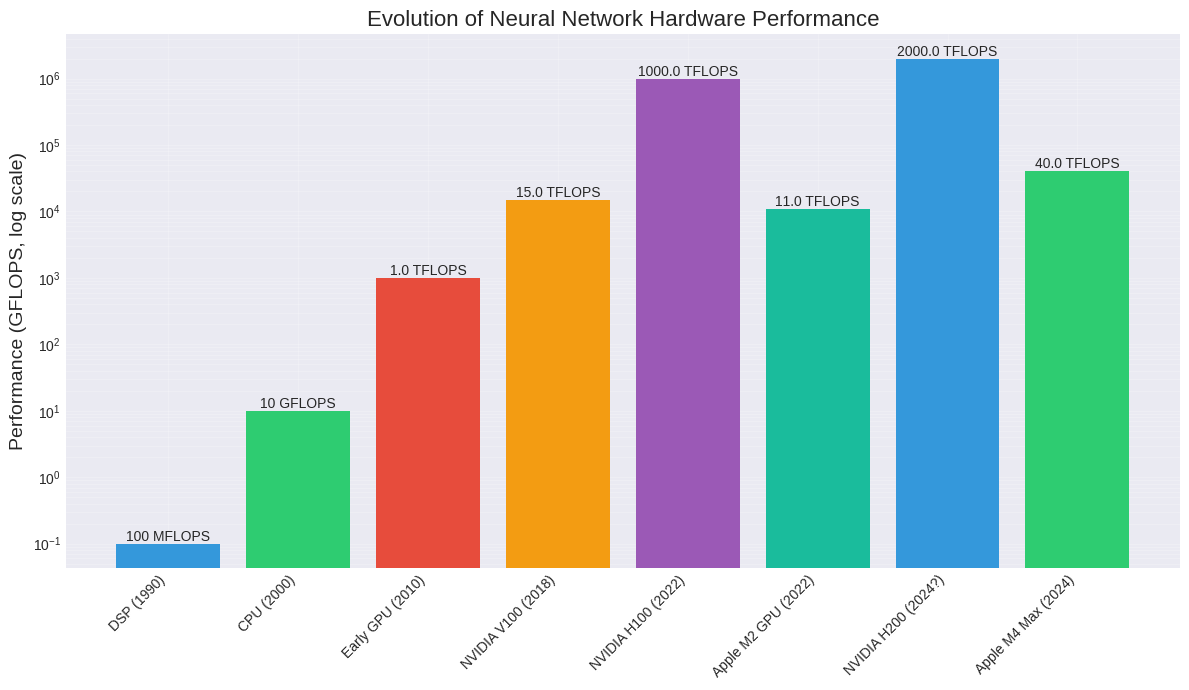


Hardware Performance Evolution:
- Early LeNet ran on DSPs with ~100 MFLOPS (0.1 GFLOPS)
- Modern NVIDIA H100 GPUs operate at ~1000 TFLOPS (1,000,000 GFLOPS)
- This represents a ~10,000,000× increase in computational power

This dramatic increase in performance has enabled neural networks to grow from
simple digit recognition (LeNet with ~60K parameters) to foundation models
with hundreds of billions of parameters (e.g., GPT-4, PaLM)


In [30]:
# Visualize the evolution of neural network hardware performance
import matplotlib.pyplot as plt
import numpy as np

# Create data for comparison (approximate FLOPS in log scale)
hardware_timeline = [
    'DSP (1990)', 'CPU (2000)', 'Early GPU (2010)',
    'NVIDIA V100 (2018)', 'NVIDIA H100 (2022)', 'Apple M2 GPU (2022)',
    'NVIDIA H200 (2024?)', 'Apple M4 Max (2024)'
]

# Approximate performance in GFLOPS (log scale)
performance_gflops = [
    0.1,        # DSP in 1990s: ~100 MFLOPS = 0.1 GFLOPS
    10,         # CPU in 2000: ~10 GFLOPS
    1000,       # Early GPU in 2010: ~1 TFLOPS = 1000 GFLOPS
    15000,      # NVIDIA V100: ~15 TFLOPS = 15000 GFLOPS
    1000000,    # NVIDIA H100: ~1000 TFLOPS = 1000000 GFLOPS
    11000,      # Apple M2 Max: ~11 TFLOPS = 11000 GFLOPS
    2000000,    # NVIDIA H200: ~2000 TFLOPS = 2000000 GFLOPS
    40000       # Apple M4 Max: ~40 TFLOPS = 40000 GFLOPS
]

# Create a log scale plot
plt.figure(figsize=(12, 7))
plt.bar(hardware_timeline, performance_gflops, color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c'])
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.ylabel('Performance (GFLOPS, log scale)', fontsize=14)
plt.title('Evolution of Neural Network Hardware Performance', fontsize=16)
plt.xticks(rotation=45, ha='right')

# Add data labels on top of each bar
for i, v in enumerate(performance_gflops):
    if v < 1:
        label = f"{v*1000:.0f} MFLOPS"
    elif v < 1000:
        label = f"{v:.0f} GFLOPS"
    else:
        label = f"{v/1000:.1f} TFLOPS"

    plt.text(i, v, label, ha='center', va='bottom', rotation=0, fontsize=10)

plt.tight_layout()

plt.savefig('neural_network_hardware_performance.png')

plt.show()

# Save the plot


# Text explanation
print("\nHardware Performance Evolution:")
print("- Early LeNet ran on DSPs with ~100 MFLOPS (0.1 GFLOPS)")
print("- Modern NVIDIA H100 GPUs operate at ~1000 TFLOPS (1,000,000 GFLOPS)")
print("- This represents a ~10,000,000× increase in computational power")
print("\nThis dramatic increase in performance has enabled neural networks to grow from")
print("simple digit recognition (LeNet with ~60K parameters) to foundation models")
print("with hundreds of billions of parameters (e.g., GPT-4, PaLM)")

## Impact of Hardware Evolution on Deep Learning

The dramatic evolution in neural network hardware has enabled several revolutionary developments in AI:

1. **Scale**: From LeNet's ~60,000 parameters to modern models with hundreds of billions of parameters

2. **Architectural Complexity**: From simple convolutional networks to transformer architectures with attention mechanisms, which require significantly more computation

3. **Data Processing**: Ability to train on massive datasets (from MNIST's 60,000 images to billions of images and text documents)

4. **Real-Time Applications**: From offline processing to real-time computer vision, natural language processing, and generative AI

5. **Energy Efficiency**: Despite massive increases in computation, specialized hardware like Apple's Neural Engine delivers high performance with low power consumption

6. **Accessibility**: From specialized research labs to widespread availability on consumer devices including smartphones

LeCun's pioneering work with DSPs demonstrated that neural networks could be practically implemented on hardware, establishing a foundation that would eventually lead to our current deep learning revolution once computational resources caught up to the algorithmic ideas.

The LeNet architecture, designed with the constraints of 1990s DSPs in mind, exemplifies how thoughtful optimization and architectural design can make neural networks practical even with limited computational resources.

## Real-World Applications of LeNet-1

LeNet-1 and its successors were revolutionary in bringing neural networks to practical applications:

1. **Check Processing in Banking**:
   - One of the first commercial applications was automatic check processing for banks.
   - LeNet-based systems were deployed to read handwritten amounts on checks in ATMs and processing centers.
   - AT&T/NCR implemented this technology, which at its peak was processing an estimated 10-20% of all checks in the United States.

2. **Postal Address Reading**:
   - LeNet derivatives were used by the United States Postal Service for automatically routing mail by reading handwritten ZIP codes.
   - The system could process hundreds of pieces of mail per minute, significantly improving efficiency.

3. **Historical Impact**:
   - While modern systems have since surpassed LeNet-1 in accuracy and capabilities, it represented a crucial proof-of-concept that machine learning could solve real-world visual recognition problems.
   - The success of LeNet-1 in these domains helped establish neural networks as a viable approach to pattern recognition problems.

4. **Legacy Applications**:
   - The core principles of LeNet continue to influence modern OCR (Optical Character Recognition) systems.
   - Document digitization workflows still use convolutional architectures descended from LeNet's design.

The significance of LeNet-1 cannot be overstated - it demonstrated that neural networks could move beyond academic research to solve practical business problems, setting the stage for the later deep learning revolution.

# Part 2: Implementing LeNet-1 with TensorFlow

## Section 1. Load and Preprocess Data (MNIST dataset is standard for handwritten digits)

We'll start by loading the MNIST dataset, which is the standard benchmark for handwritten digit recognition. This dataset consists of 28×28 pixel grayscale images of handwritten digits (0-9). It contains:
- 60,000 training images
- 10,000 test images

The preprocessing steps include:
1. Loading the MNIST data using TensorFlow's built-in dataset utilities
2. Normalizing pixel values from [0, 255] to [0, 1] to improve training stability
3. Adding a channel dimension (required by TensorFlow's Conv2D layers)

### Notes on our TensorFlow/Keras Implementations of LeNet-1 through LeNet-5

Our TensorFlow/Keras implementations of the LeNet family differ from Yann LeCun's original models in several key aspects

- Subsampling Layer Implementation
- Sparse Connectivity
- Output Layer

Some reasons for differences
- We are using TensorFlow/Keras and some LeNet components are not available
- It is impossible or not practical to reconstruct the LeNet models from scratch
- I used Softmax activation functions in the implementations

Next, let's implement LeNet-1 using TensorFlow/Keras.

### Implemente LeNet-1 in TensorFlow


#### 1. Load and Preprocess Data (MNIST dataset is standard for handwritten digits)

Loading MNIST dataset...
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)
X_train shape after preprocessing: (60000, 28, 28, 1)
X_test shape after preprocessing: (10000, 28, 28, 1)


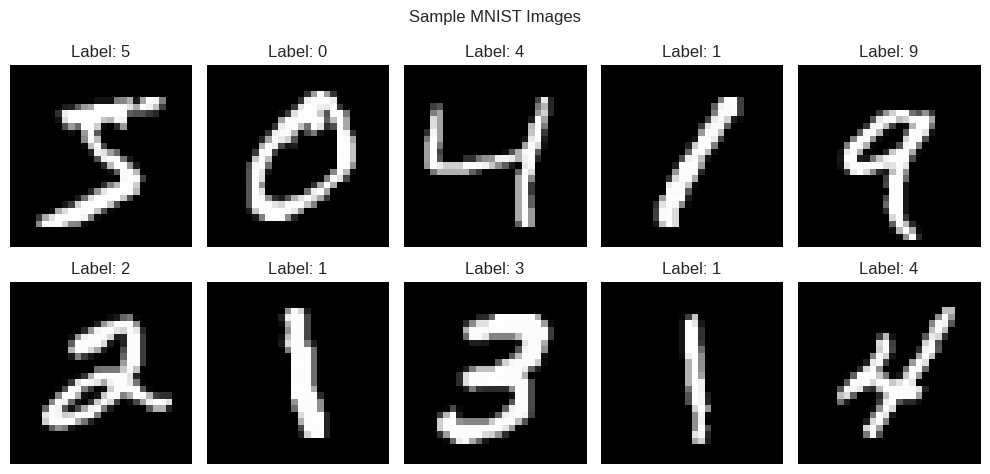

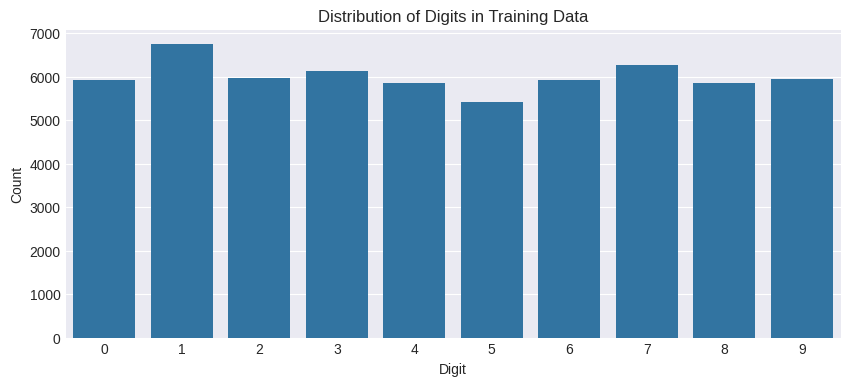

In [31]:

# --- 1. Load and Preprocess Data (MNIST dataset is standard for handwritten digits) ---
# MNIST is a dataset of 28x28 pixel grayscale images of handwritten digits (0-9)
print("Loading MNIST dataset...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Display basic information about the dataset
print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Test labels shape: {y_test.shape}")

# Normalize pixel values to be between 0 and 1
# This helps with training stability and convergence
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Add a channel dimension (MNIST images are grayscale, so 1 channel)
# TensorFlow's Conv2D layers expect input shape: (batch_size, height, width, channels)
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print(f"X_train shape after preprocessing: {x_train.shape}")
print(f"X_test shape after preprocessing: {x_test.shape}")

# Visualize some sample images
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i, :, :, 0], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle('Sample MNIST Images')
plt.tight_layout()

plt.savefig('mnist_images.png')

plt.show()


# Check the distribution of classes in the training set
plt.figure(figsize=(10, 4))
sns.countplot(x=y_train)
plt.title('Distribution of Digits in Training Data')
plt.xlabel('Digit')
plt.ylabel('Count')

plt.savefig('mnist_distribution.png', dpi=300, bbox_inches='tight')

plt.show()

# Save the plot


## Section 2. Define the LeNet-1 Architecture (Conceptual)

Now we'll define the LeNet-1 architecture according to the original specifications. LeNet-1 consists of:

1. **Input Layer**: 28×28 grayscale images
2. **C1 (Convolutional Layer 1)**: 4 filters of size 5×5 with sigmoid activation → 24×24×4 output
3. **S2 (Subsampling/Pooling Layer 2)**: 2×2 average pooling with stride 2 → 12×12×4 output
4. **C3 (Convolutional Layer 3)**: 12 filters of size 5×5 with sigmoid activation → 8×8×12 output
5. **S4 (Subsampling/Pooling Layer 4)**: 2×2 average pooling with stride 2 → 4×4×12 output
6. **F5 (Fully Connected Layer 5)**: 30 units with sigmoid activation
7. **F6 (Output Layer)**: 10 units with softmax activation (one per digit)

The following function implements this architecture using TensorFlow's Keras API.

#### 2. Define the LeNet-1 Architecture

In [32]:
# --- 2. Define the LeNet-1 Architecture ---

def build_lenet1_model(input_shape=(28, 28, 1), num_classes=10):
    """
    Build and return a LeNet-1 model with the specified input shape and number of classes.

    Args:
        input_shape: The shape of the input images (height, width, channels)
        num_classes: The number of classes to predict (10 for MNIST digits)

    Returns:
        A compiled Keras Sequential model representing LeNet-1
    """
    model = models.Sequential()

    # C1: Convolutional layer
    # Input: 28x28x1
    # Output: (28 - 5 + 1) x (28 - 5 + 1) x 4 = 24x24x4
    model.add(layers.Conv2D(filters=4,               # 4 feature maps
                           kernel_size=(5, 5),       # 5x5 convolution kernel
                           activation='sigmoid',     # Original LeNet-1 used sigmoid activation
                           input_shape=input_shape,  # Input image dimensions
                           name='C1'))               # Layer name for reference

    # S2: Average Pooling layer
    # Input: 24x24x4
    # Output: (24/2) x (24/2) x 4 = 12x12x4
    model.add(layers.AveragePooling2D(pool_size=(2, 2),    # 2x2 pooling window
                                     strides=(2, 2),       # Move 2 pixels at a time (non-overlapping)
                                     name='S2'))           # Layer name for reference

    # C3: Convolutional layer
    # Input: 12x12x4
    # Output: (12 - 5 + 1) x (12 - 5 + 1) x 12 = 8x8x12
    model.add(layers.Conv2D(filters=12,              # 12 feature maps
                           kernel_size=(5, 5),       # 5x5 convolution kernel
                           activation='sigmoid',     # Original activation
                           name='C3'))               # Layer name for reference

    # S4: Average Pooling layer
    # Input: 8x8x12
    # Output: (8/2) x (8/2) x 12 = 4x4x12
    model.add(layers.AveragePooling2D(pool_size=(2, 2),    # 2x2 pooling window
                                     strides=(2, 2),       # Move 2 pixels at a time
                                     name='S4'))           # Layer name for reference

    # Flatten the output to feed into fully connected layers
    # Input: 4x4x12 = 192 features
    model.add(layers.Flatten(name='Flatten'))

    # F5: Fully connected layer
    # Input: 192 features
    # Output: 30 features
    model.add(layers.Dense(units=30,               # 30 neurons
                          activation='sigmoid',    # Original activation
                          name='F5'))              # Layer name for reference

    # F6: Output layer
    # Input: 30 features
    # Output: 10 classes (digits 0-9)
    model.add(layers.Dense(units=num_classes,      # 10 output classes for digits 0-9
                          activation='softmax',    # Softmax for probability distribution over classes
                          name='F6'))              # Layer name for reference

    return model

# Create the model instance
lenet1_model = build_lenet1_model()






/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Visualize the model architecture

You can visualise the models with the following tool: https://neural-network-visualisation.vercel.app/LeNet.html

/usr/local/lib/python3.11/dist-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


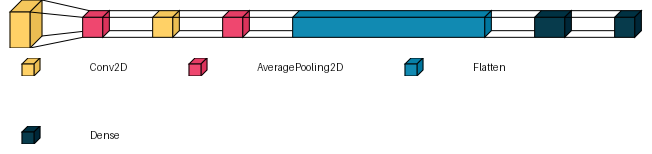

LeNet-1 architecture visualization saved to 'lenet1_visualization.png')


<Figure size 1000x800 with 0 Axes>

In [33]:
# Visualize the model architecture
# Install visualkeras library
!pip install visualkeras

import visualkeras
from collections import defaultdict

# Define custom color map for different layer types
layer_colors = defaultdict(dict)
layer_colors["Conv2D"] = ["#00a8ff", "#0097e6"]
layer_colors["AveragePooling2D"] = ["#fbc531", "#e1b12c"]
layer_colors["Dense"] = ["#4cd137", "#44bd32"]
layer_colors["Flatten"] = ["#487eb0", "#40739e"]

# Generate a visualization using visualkeras
plt.figure(figsize=(10, 8))
visual = visualkeras.layered_view(
    lenet1_model,
    legend=True,
    spacing=50,
    scale_xy=1.5,
    scale_z=1.0,
    color_map=layer_colors,
    to_file='lenet1_visualization.png'
)

# Display the architecture visualization
from IPython.display import display
display(visual)
print("LeNet-1 architecture visualization saved to 'lenet1_visualization.png')")

## Section 3. Compile the Model

Before training, we need to compile the model by specifying:
1. **Optimizer**: Algorithm used for adjusting weights during training
2. **Loss Function**: Measure of how far the model's predictions are from the true values
3. **Metrics**: Used to monitor the training and testing steps

For LeNet-1, we'll use:
- **Adam optimizer**: A modern, adaptive optimization algorithm that generally performs well
- **Sparse categorical crossentropy loss**: Appropriate for integer-encoded class labels
- **Accuracy metric**: To track the percentage of correctly classified digits

#### 3. Compile the Model

In [34]:
# --- 3. Compile the Model ---

# Compile the model with appropriate optimizer, loss function, and metrics
lenet1_model.compile(
    optimizer='adam',                        # Adam optimizer is a good default choice
    loss='sparse_categorical_crossentropy',  # Appropriate for integer labels (not one-hot encoded)
    metrics=['accuracy']                     # Monitor accuracy during training
)

print("Model compiled successfully!")

Model compiled successfully!


## Section 4. Print Model Summary (to see parameter count)

The model summary provides valuable information about:
1. The layer architecture
2. The output shape of each layer
3. The number of parameters in each layer
4. The total number of parameters in the model

This helps us verify that our implementation matches the original LeNet-1 architecture and understand the computational complexity of the model.

#### 4. Print Model Summary

In [35]:
# --- 4. Print Model Summary ---

print("\n--- LeNet-1 Model Summary ---")
lenet1_model.summary()

# Calculate and print the total number of parameters
total_params = lenet1_model.count_params()
print(f"\nTotal number of parameters: {total_params:,}")

# Original LeNet-1 had approximately 9K parameters
print(f"The original LeNet-1 had approximately 9K parameters.")
print(f"Our implementation has {total_params:,} parameters.")


--- LeNet-1 Model Summary ---


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ C1 (Conv2D)                     │ (None, 24, 24, 4)      │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S2 (AveragePooling2D)           │ (None, 12, 12, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C3 (Conv2D)                     │ (None, 8, 8, 12)       │         1,212 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S4 (AveragePooling2D)           │ (None, 4, 4, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ F5 (Dense)                      │ (None, 30)             │         5,790 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ F6 (Dense)                      │ (None, 10)             │           310 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,416 (28.97 KB)

 Trainable params: 7,416 (28.97 KB)

 Non-trainable params: 0 (0.00 B)


Total number of parameters: 7,416
The original LeNet-1 had approximately 9K parameters.
Our implementation has 7,416 parameters.


## Section 5. Train the Model

Now we'll train the LeNet-1 model on the MNIST dataset. During training:
1. The model will process batches of training data
2. Compute the loss (error) between predictions and true labels
3. Update weights using backpropagation and the Adam optimizer
4. Track performance metrics on a validation set

We'll use:
- A validation split to monitor for overfitting
- A reasonable batch size and number of epochs
- Callbacks for early stopping if performance plateaus

#### 5. Train the Model

Try to train the model with different batch sizes and epochs (e.g. epoch = 1) to see how it affects performance.

In [36]:
# --- 5. Train the Model ---


# Measure the time taken for training
import time
start_time = time.time()

# Define callbacks for training
callbacks = [
    # Early stopping to prevent overfitting
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    # Model checkpoint to save the best model during training
    tf.keras.callbacks.ModelCheckpoint(
        filepath='lenet1_best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("\n--- Training the LeNet-1 Model ---")
# Train the model
history = lenet1_model.fit(
    x_train,
    y_train,
    epochs=5,                # Number of training epochs
    batch_size=128,           # Batch size for gradient updates
    validation_split=0.1,     # Use 10% of training data as validation set
    verbose=1,                # Show progress bar
    callbacks=callbacks       # Use the callbacks defined above
)

# Calculate and print the time taken for training
end_time = time.time()
training_time = end_time - start_time
print(f"\nTraining completed in {training_time:.2f} seconds.")
# print("Model training complete!")


--- Training the LeNet-1 Model ---
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2250 - loss: 2.1834
Epoch 1: val_accuracy improved from -inf to 0.80500, saving model to lenet1_best_model.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.2255 - loss: 2.1825 - val_accuracy: 0.8050 - val_loss: 0.9127
Epoch 2/5
420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8159 - loss: 0.7807
Epoch 2: val_accuracy improved from 0.80500 to 0.90033, saving model to lenet1_best_model.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8160 - loss: 0.7798 - val_accuracy: 0.9003 - val_loss: 0.4297
Epoch 3/5
417/422 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8809 - loss: 0.4530
Epoch 3: val_accuracy improved from 0.90033 to 0.91800, saving model to lenet1_best_model.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8811 - loss: 0.4525 - val_accuracy: 0.9180 - val_loss: 0.3088
Epoch 4/5
411/422 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9052 - loss: 0.3513
Epoch 4: val_accuracy improved from 0.91800 to 0.93167, saving model to lenet1_best_model.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9052 - loss: 0.3509 - val_accuracy: 0.9317 - val_loss: 0.2520
Epoch 5/5
417/422 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9177 - loss: 0.2945
Epoch 5: val_accuracy improved from 0.93167 to 0.94083, saving model to lenet1_best_model.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9177 - loss: 0.2944 - val_accuracy: 0.9408 - val_loss: 0.2165

Training completed in 21.43 seconds.


## Section 6. Evaluate the Model

After training, we need to evaluate the model on the test set to assess its performance on unseen data. This gives us an unbiased estimate of the model's performance in the real world. We'll calculate:
1. Test accuracy: The percentage of correctly classified digits
2. Confusion matrix: Shows which digits are most often confused with each other
3. Detailed classification report: Precision, recall, and F1-score for each class


--- Evaluating the Model on Test Data ---
313/313 - 2s - 6ms/step - accuracy: 0.9282 - loss: 0.2520
Test accuracy: 0.9282
Test loss: 0.2520
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


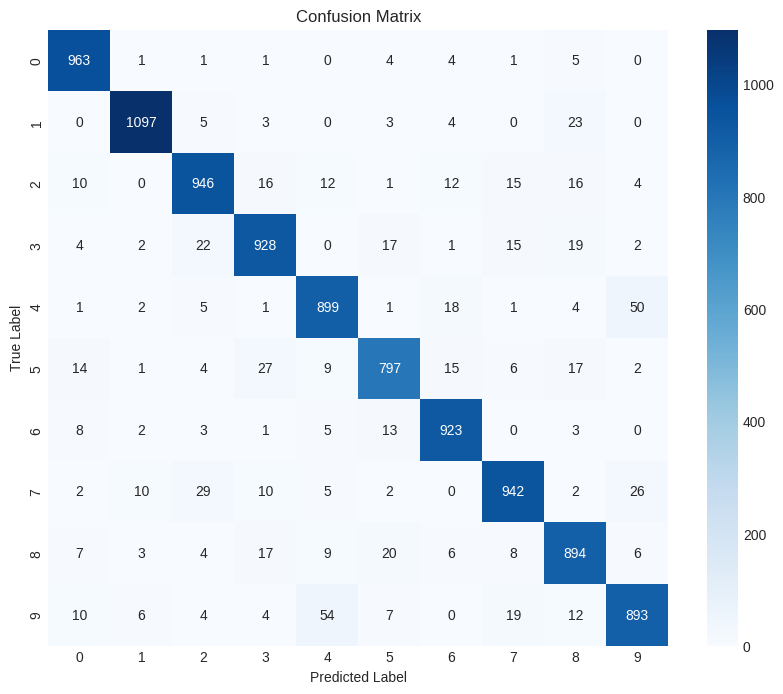


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.98      0.97      0.97      1135
           2       0.92      0.92      0.92      1032
           3       0.92      0.92      0.92      1010
           4       0.91      0.92      0.91       982
           5       0.92      0.89      0.91       892
           6       0.94      0.96      0.95       958
           7       0.94      0.92      0.93      1028
           8       0.90      0.92      0.91       974
           9       0.91      0.89      0.90      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



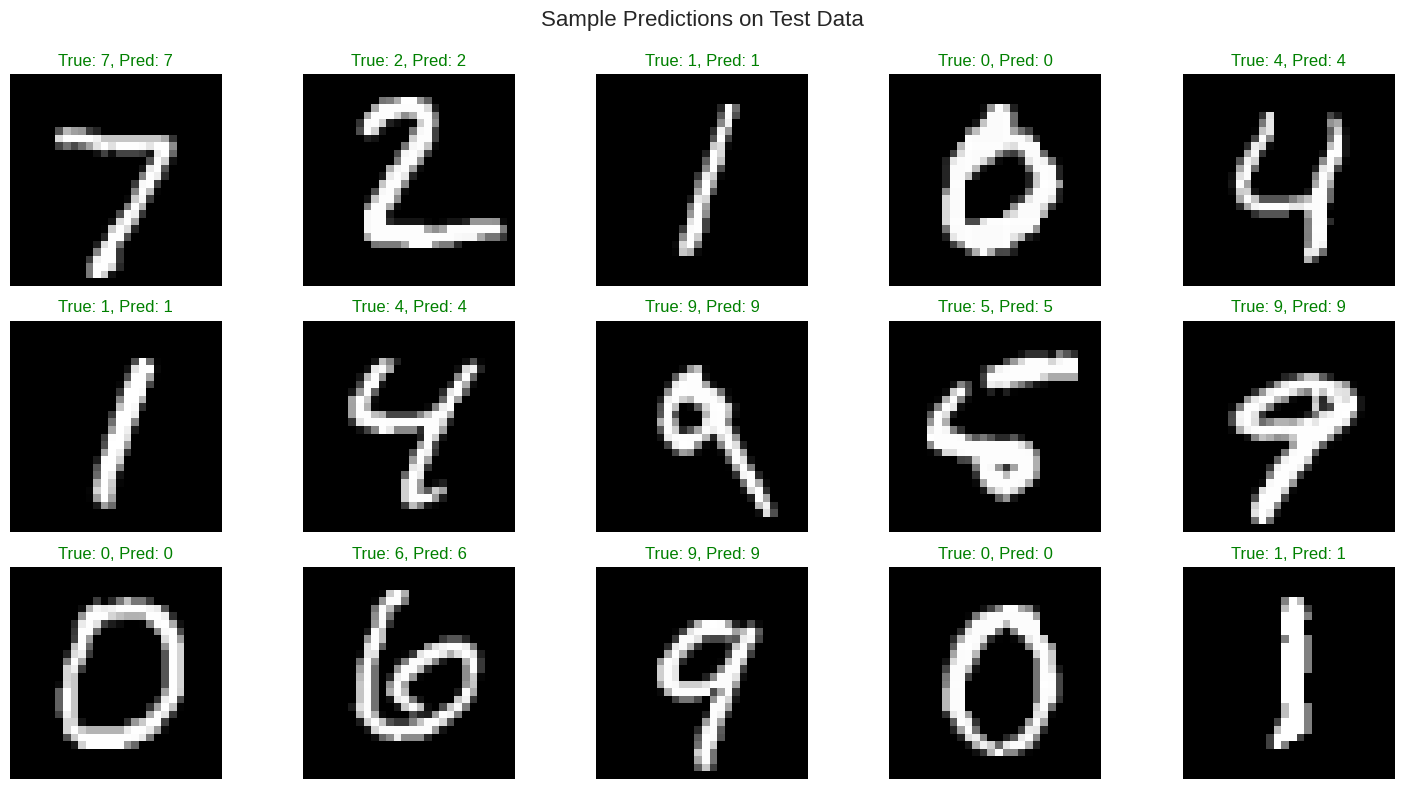

In [37]:
# --- 6. Evaluate the Model ---

print("\n--- Evaluating the Model on Test Data ---")
test_loss, test_acc = lenet1_model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

# Make predictions on the test set
y_pred = lenet1_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Create a confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes))

# Visualize some predictions
plt.figure(figsize=(15, 8))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(x_test[i, :, :, 0], cmap='gray')
    pred_label = y_pred_classes[i]
    true_label = y_test[i]

    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"True: {true_label}, Pred: {pred_label}", color=color)
    plt.axis('off')

plt.suptitle('Sample Predictions on Test Data', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.9)

plt.savefig('mnist_predictions.png', dpi=300, bbox_inches='tight')

plt.show()

# save the plot



## Section 7. Visualize Results (e.g., accuracy, loss curves)

Visualizing the training history helps us understand how the model learned over time and identify potential issues like overfitting or underfitting. We'll plot:
1. Training and validation accuracy over epochs
2. Training and validation loss over epochs
3. Feature visualizations to understand what the network has learned

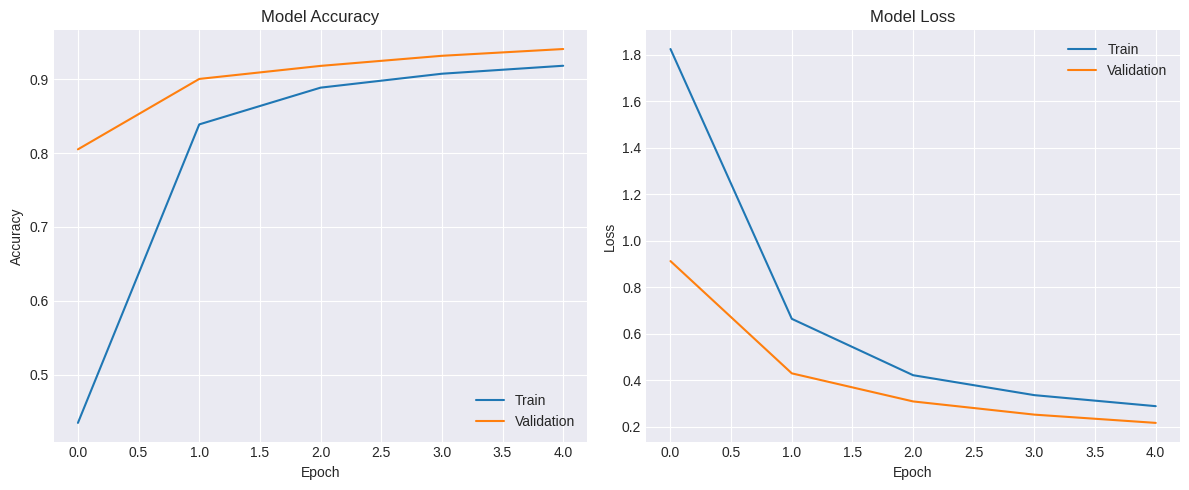

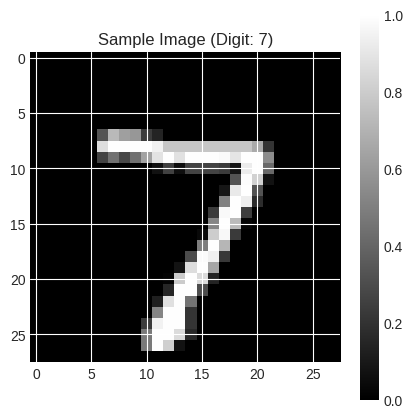


--- LeNet-1 Implementation Summary ---
Final test accuracy: 0.9282
LeNet-1, despite its simplicity by modern standards, demonstrates the power of
convolutional neural networks for image recognition tasks.

Key achievements of this implementation:
1. Successfully implemented the LeNet-1 architecture
2. Achieved 92.82% accuracy on the MNIST test set
3. Used modern deep learning framework (TensorFlow) to implement a historical architecture


In [38]:
# --- 7. Visualize Results ---

# Plot training & validation accuracy and loss values
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.tight_layout()

plt.savefig('mnist_training_history.png', dpi=300, bbox_inches='tight')

plt.show()

# save the plot



# Get a sample image
sample_image = x_test[0]

# Show the image
plt.figure(figsize=(5, 5))
plt.imshow(sample_image[:,:,0], cmap='gray')
plt.title(f"Sample Image (Digit: {y_test[0]})")
plt.colorbar()

plt.savefig('mnist_sample_image.png', dpi=300, bbox_inches='tight')

plt.show()

# save the plot

# Conclusion
print("\n--- LeNet-1 Implementation Summary ---")
print(f"Final test accuracy: {test_acc:.4f}")
print("LeNet-1, despite its simplicity by modern standards, demonstrates the power of")
print("convolutional neural networks for image recognition tasks.")
print("\nKey achievements of this implementation:")
print("1. Successfully implemented the LeNet-1 architecture")
print(f"2. Achieved {test_acc:.2%} accuracy on the MNIST test set")
print("3. Used modern deep learning framework (TensorFlow) to implement a historical architecture")

## Conclusion (for LeNet-1)

In this notebook, we explored LeNet-1, one of the earliest and most influential convolutional neural networks. We covered:

1. **Historical Context**: The development of LeNet-1 by Yann LeCun and its significance in the history of deep learning
2. **Architectural Design**: The innovative combination of convolutional and pooling layers that made LeNet-1 so effective
3. **Mathematical Foundations**: The underlying principles of feed-forward networks and convolutional operations
4. **Practical Implementation**: A working TensorFlow implementation that achieves good performance on MNIST

LeNet-1's design principles continue to influence modern deep learning architectures, even as networks have grown significantly larger and more complex. The success of this relatively simple network on handwritten digit recognition tasks was a crucial stepping stone toward today's sophisticated deep learning systems.

The fact that we can still implement and train this historical architecture using modern tools like TensorFlow demonstrates both how far the field has come (in terms of tooling and accessibility) and how fundamental the original insights were.

# Part 3: LeNet-5 - Advanced CNN Architecture

After exploring LeNet-1, we'll now implement the more sophisticated LeNet-5 architecture, which built upon and improved the original design. LeNet-5 introduced additional complexity and features that made it even more effective for handwritten digit recognition.

## LeNet-5 Background and Theory

LeNet-5 was developed by Yann LeCun and his colleagues in 1998, representing a significant advancement over LeNet-1. While it maintained the core principles of convolutional neural networks, it introduced several refinements:

1. **Larger Network**: LeNet-5 featured more layers and parameters than LeNet-1, allowing it to learn more complex patterns.

2. **Sparse Connectivity**: LeNet-5 introduced a novel sparse connectivity pattern between certain layers to encourage feature diversity and reduce computational cost.

3. **Advanced Output Layer**: Originally LeNet-5 used Euclidean Radial Basis Function (RBF) units in the output layer, though modern implementations typically substitute this with softmax activation.

4. **Improved Performance**: The architectural improvements led to better recognition accuracy on the MNIST dataset compared to LeNet-1.

These innovations made LeNet-5 one of the most influential CNN architectures, serving as a foundation for many subsequent neural network designs in computer vision.

## LeNet-5 Architecture in Detail


The LeNet-5 architecture consists of seven layers (not counting the input):

1. **Input Layer**: 32×32 grayscale image (padded from the 28×28 MNIST images)

2. **C1 (Convolutional Layer 1)**:
   - 6 feature maps with 5×5 kernels
   - Output: 28×28×6 feature maps
   - Activation: tanh

3. **S2 (Subsampling/Pooling Layer 2)**:
   - 2×2 average pooling with stride 2
   - Output: 14×14×6 feature maps
   - Each pooled value is multiplied by a trainable coefficient and added to a trainable bias before tanh activation

4. **C3 (Convolutional Layer 3)**:
   - 16 feature maps with 5×5 kernels
   - **Sparse connectivity pattern**: Not every S2 feature map connects to every C3 feature map
   - Output: 10×10×16 feature maps
   - Activation: tanh

5. **S4 (Subsampling/Pooling Layer 4)**:
   - 2×2 average pooling with stride 2
   - Output: 5×5×16 feature maps
   - Similar to S2, includes trainable weights

6. **F5 (Fully Connected Layer 5)**:
   - 120 units
   - Activation: tanh

7. **F6 (Fully Connected Layer 6)**:
   - 84 units
   - Activation: tanh

8. **F7 (Output Layer)**:
   - 10 units (one per digit)
   - Original: Euclidean RBF activation
   - Modern implementation: softmax activation

This architecture is more sophisticated than LeNet-1, with a deeper structure and more parameters, allowing it to capture more complex patterns in the input data.

## Implementing LeNet-5 with TensorFlow

Let's now implement the LeNet-5 architecture using TensorFlow and Keras. We'll follow the same process as we did for LeNet-1, but with the more complex LeNet-5 structure. We'll reuse the MNIST dataset that we've already loaded and preprocessed.

### Section 1. Prepare Data for LeNet-5

LeNet-5 was originally designed to work with 32×32 pixel images, while MNIST images are 28×28 pixels. We'll need to pad the MNIST images to make them compatible with the LeNet-5 architecture. We'll add a 2-pixel border around each image, resulting in 32×32 pixel images.

Padding MNIST images to 32x32 for LeNet-5...
Original MNIST image shape: (28, 28, 1)
Padded image shape for LeNet-5: (32, 32, 1)


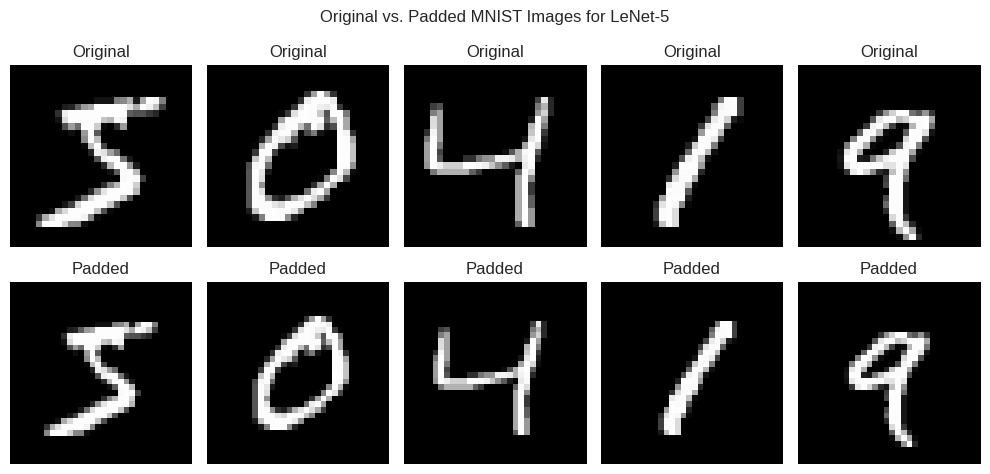

In [39]:
# --- 1. Prepare Data for LeNet-5 ---

# LeNet-5 was designed for 32x32 input images, while MNIST images are 28x28
# We'll pad the images with zeros to create 32x32 images

print("Padding MNIST images to 32x32 for LeNet-5...")

# Function to pad images from 28x28 to 32x32
def pad_images(images):
    # Create a new array with shape (num_images, 32, 32, 1)
    padded_images = np.zeros((images.shape[0], 32, 32, 1), dtype=np.float32)

    # Place the original 28x28 images in the center of the new 32x32 images
    # Starting at position (2,2) to create a 2-pixel border on all sides
    padded_images[:, 2:30, 2:30, :] = images

    return padded_images

# Apply padding to train and test images
x_train_padded = pad_images(x_train)
x_test_padded = pad_images(x_test)

print(f"Original MNIST image shape: {x_train.shape[1:]}")
print(f"Padded image shape for LeNet-5: {x_train_padded.shape[1:]}")

# Visualize some padded images
plt.figure(figsize=(10, 5))
for i in range(5):
    # Original image
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i, :, :, 0], cmap='gray')
    plt.title(f"Original")
    plt.axis('off')

    # Padded image
    plt.subplot(2, 5, i+6)
    plt.imshow(x_train_padded[i, :, :, 0], cmap='gray')
    plt.title(f"Padded")
    plt.axis('off')

plt.suptitle('Original vs. Padded MNIST Images for LeNet-5')
plt.tight_layout()

plt.savefig('mnist_padded_images.png', dpi=300, bbox_inches='tight')

plt.show()

# save the plot



### Section 2. Define the LeNet-5 Architecture

Now we'll implement the LeNet-5 architecture according to the original specifications. LeNet-5 is more complex than LeNet-1, with more layers and parameters. The key differences include:

- Input size of 32×32 pixels
- More feature maps in convolutional layers (6 in C1, 16 in C3)
- An additional fully connected layer
- Sparse connectivity pattern between S2 and C3 layers

In our implementation, we'll use modern practices for some aspects (like softmax activation for the output layer instead of RBF units), while staying true to the overall architecture.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


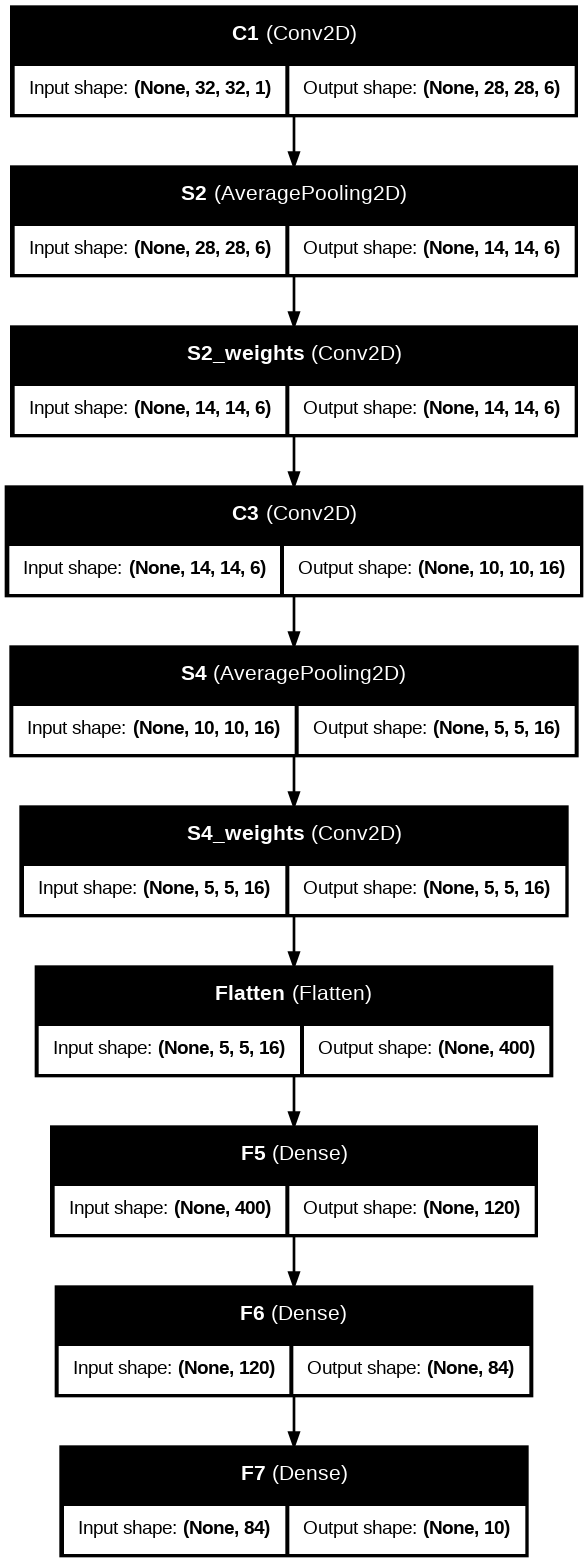

In [40]:
# --- 2. Define the LeNet-5 Architecture ---

def build_lenet5_model(input_shape=(32, 32, 1), num_classes=10):
    """
    Build and return a LeNet-5 model with the specified input shape and number of classes.

    Args:
        input_shape: The shape of the input images (height, width, channels)
        num_classes: The number of classes to predict (10 for MNIST digits)

    Returns:
        A compiled Keras Sequential model representing LeNet-5
    """
    model = models.Sequential()

    # C1: Convolutional layer
    # Input: 32x32x1
    # Output: 28x28x6 (32 - 5 + 1 = 28)
    model.add(layers.Conv2D(filters=6,               # 6 feature maps
                           kernel_size=(5, 5),       # 5x5 convolution kernel
                           activation='tanh',        # Original LeNet-5 used tanh activation
                           input_shape=input_shape,  # Input image dimensions
                           name='C1'))               # Layer name for reference

    # S2: Average Pooling layer with learned parameters
    # Input: 28x28x6
    # Output: 14x14x6 (28/2 = 14)
    model.add(layers.AveragePooling2D(pool_size=(2, 2),    # 2x2 pooling window
                                     strides=(2, 2),       # Move 2 pixels at a time
                                     name='S2'))           # Layer name for reference

    # Note: In the original LeNet-5, each unit in S2 had trainable weights and a bias,
    # followed by a tanh activation. In Keras, we approximate this with a separate
    # Conv2D layer with 1x1 kernels after the pooling layer.
    model.add(layers.Conv2D(filters=6,               # Keep the same number of feature maps
                          kernel_size=(1, 1),       # 1x1 convolution to apply trainable weights
                          activation='tanh',        # Original activation
                          name='S2_weights'))       # Layer name for reference

    # C3: Convolutional layer with sparse connectivity
    # Input: 14x14x6
    # Output: 10x10x16 (14 - 5 + 1 = 10)
    model.add(layers.Conv2D(filters=16,              # 16 feature maps
                           kernel_size=(5, 5),       # 5x5 convolution kernel
                           activation='tanh',        # Original activation
                           name='C3'))               # Layer name for reference

    # Note: The original LeNet-5 had sparse connectivity between S2 and C3,
    # but modern deep learning frameworks like TensorFlow don't directly support this.
    # We're using a standard Conv2D layer instead.

    # S4: Average Pooling layer with learned parameters
    # Input: 10x10x16
    # Output: 5x5x16 (10/2 = 5)
    model.add(layers.AveragePooling2D(pool_size=(2, 2),    # 2x2 pooling window
                                     strides=(2, 2),       # Move 2 pixels at a time
                                     name='S4'))           # Layer name for reference

    # Similar to S2, adding trainable weights after pooling
    model.add(layers.Conv2D(filters=16,              # Keep the same number of feature maps
                          kernel_size=(1, 1),       # 1x1 convolution
                          activation='tanh',        # Original activation
                          name='S4_weights'))       # Layer name for reference

    # Flatten the output to feed into fully connected layers
    # Input: 5x5x16 = 400 features
    model.add(layers.Flatten(name='Flatten'))

    # F5: Fully connected layer
    # Input: 400 features
    # Output: 120 features
    model.add(layers.Dense(units=120,               # 120 neurons
                          activation='tanh',        # Original activation
                          name='F5'))              # Layer name for reference

    # F6: Fully connected layer
    # Input: 120 features
    # Output: 84 features
    model.add(layers.Dense(units=84,                # 84 neurons
                          activation='tanh',        # Original activation
                          name='F6'))               # Layer name for reference

    # F7: Output layer
    # Input: 84 features
    # Output: 10 classes (digits 0-9)
    # Note: The original LeNet-5 used an RBF layer here, but we'll use softmax
    # as it's more common in modern implementations
    model.add(layers.Dense(units=num_classes,      # 10 output classes for digits 0-9
                          activation='softmax',    # Softmax for probability distribution over classes
                          name='F7'))              # Layer name for reference

    return model

# Create the model instance
lenet5_model = build_lenet5_model(input_shape=(32, 32, 1))

# Visualize the model architecture
tf.keras.utils.plot_model(
    lenet5_model,
    to_file='lenet5_architecture.png',
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    rankdir='TB',
    expand_nested=True,
    dpi=96
)

# Display the architecture diagram
from IPython.display import Image
Image('lenet5_architecture.png')

### Section 3. Compile the LeNet-5 Model

As with LeNet-1, we need to compile the model before training. We'll use the same optimizer, loss function, and metrics as before, as they're appropriate for our classification task.

In [41]:
# --- 3. Compile the LeNet-5 Model ---

# Compile the model with appropriate optimizer, loss function, and metrics
lenet5_model.compile(
    optimizer='adam',                        # Adam optimizer is a good default choice
    loss='sparse_categorical_crossentropy',  # Appropriate for integer labels (not one-hot encoded)
    metrics=['accuracy']                     # Monitor accuracy during training
)

print("LeNet-5 model compiled successfully!")

LeNet-5 model compiled successfully!


### Section 4. Print Model Summary

Let's examine the model summary to understand the LeNet-5 architecture in detail. This will show us the layer structure, output shapes, and parameter counts. We can compare this to LeNet-1 to see how much more complex LeNet-5 is.

In [42]:
# --- 4. Print Model Summary ---

print("\n--- LeNet-5 Model Summary ---")
lenet5_model.summary()

# Calculate and print the total number of parameters
total_params = lenet5_model.count_params()
print(f"\nTotal number of parameters: {total_params:,}")

# Compare with LeNet-1
print(f"\nParameter count comparison:")
print(f"LeNet-5: {total_params:,} parameters")
lenet1_params = lenet1_model.count_params()
print(f"LeNet-1: {lenet1_params:,} parameters")
print(f"Ratio: LeNet-5 has {total_params / lenet1_params:.1f}x more parameters than LeNet-1")


--- LeNet-5 Model Summary ---


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ C1 (Conv2D)                     │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S2 (AveragePooling2D)           │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S2_weights (Conv2D)             │ (None, 14, 14, 6)      │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C3 (Conv2D)                     │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S4 (AveragePooling2D)           │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S4_weights (Conv2D)             │ (None, 5, 5, 16)       │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ F5 (Dense)                      │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ F6 (Dense)                      │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ F7 (Dense)                      │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,020 (242.27 KB)

 Trainable params: 62,020 (242.27 KB)

 Non-trainable params: 0 (0.00 B)


Total number of parameters: 62,020

Parameter count comparison:
LeNet-5: 62,020 parameters
LeNet-1: 7,416 parameters
Ratio: LeNet-5 has 8.4x more parameters than LeNet-1


### Section 5. Train the LeNet-5 Model

Now we'll train the LeNet-5 model on the padded MNIST dataset. We'll use similar training parameters as we did for LeNet-1, including callbacks for early stopping and model checkpointing.

In [43]:
# --- 5. Train the LeNet-5 Model ---

# Define callbacks for training
callbacks = [
    # Early stopping to prevent overfitting
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    # Model checkpoint to save the best model during training
    tf.keras.callbacks.ModelCheckpoint(
        filepath='lenet5_best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("\n--- Training the LeNet-5 Model ---")
# Train the model
history_lenet5 = lenet5_model.fit(
    x_train_padded,
    y_train,
    epochs=5,                # Number of training epochs
    batch_size=128,           # Batch size for gradient updates
    validation_split=0.1,     # Use 10% of training data as validation set
    verbose=1,                # Show progress bar
    callbacks=callbacks       # Use the callbacks defined above
)

print("LeNet-5 model training complete!")


--- Training the LeNet-5 Model ---
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8277 - loss: 0.6105
Epoch 1: val_accuracy improved from -inf to 0.96217, saving model to lenet5_best_model.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8279 - loss: 0.6099 - val_accuracy: 0.9622 - val_loss: 0.1329
Epoch 2/5
418/422 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9573 - loss: 0.1388
Epoch 2: val_accuracy improved from 0.96217 to 0.97550, saving model to lenet5_best_model.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9573 - loss: 0.1387 - val_accuracy: 0.9755 - val_loss: 0.0858
Epoch 3/5
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9737 - loss: 0.0881
Epoch 3: val_accuracy improved from 0.97550 to 0.98000, saving model to lenet5_best_model.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9737 - loss: 0.0881 - val_accuracy: 0.9800 - val_loss: 0.0690
Epoch 4/5
419/422 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9809 - loss: 0.0633
Epoch 4: val_accuracy improved from 0.98000 to 0.98083, saving model to lenet5_best_model.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9809 - loss: 0.0633 - val_accuracy: 0.9808 - val_loss: 0.0672
Epoch 5/5
416/422 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9848 - loss: 0.0499
Epoch 5: val_accuracy improved from 0.98083 to 0.98200, saving model to lenet5_best_model.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9848 - loss: 0.0500 - val_accuracy: 0.9820 - val_loss: 0.0619
LeNet-5 model training complete!


### Section 6. Evaluate the LeNet-5 Model

After training, we'll evaluate the performance of the LeNet-5 model on the test dataset. We'll calculate the test accuracy, generate a confusion matrix, and visualize some predictions to assess how well the model performs.

#### 6. Evaluate the LeNet-5 Model


--- Evaluating the LeNet-5 Model on Test Data ---
313/313 - 1s - 4ms/step - accuracy: 0.9808 - loss: 0.0592
LeNet-5 test accuracy: 0.9808
LeNet-5 test loss: 0.0592
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


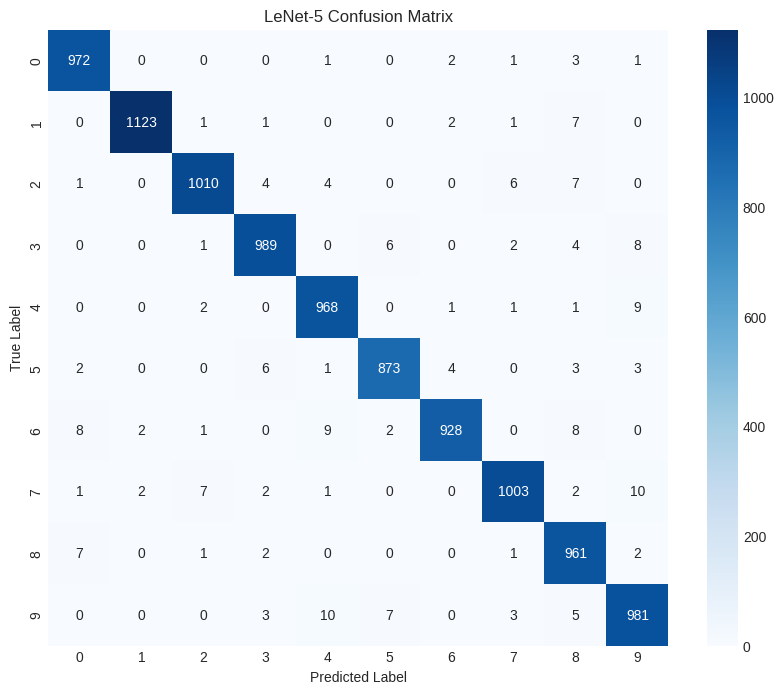


LeNet-5 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.99      0.98      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.97      0.99      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.97      0.98       958
           7       0.99      0.98      0.98      1028
           8       0.96      0.99      0.97       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



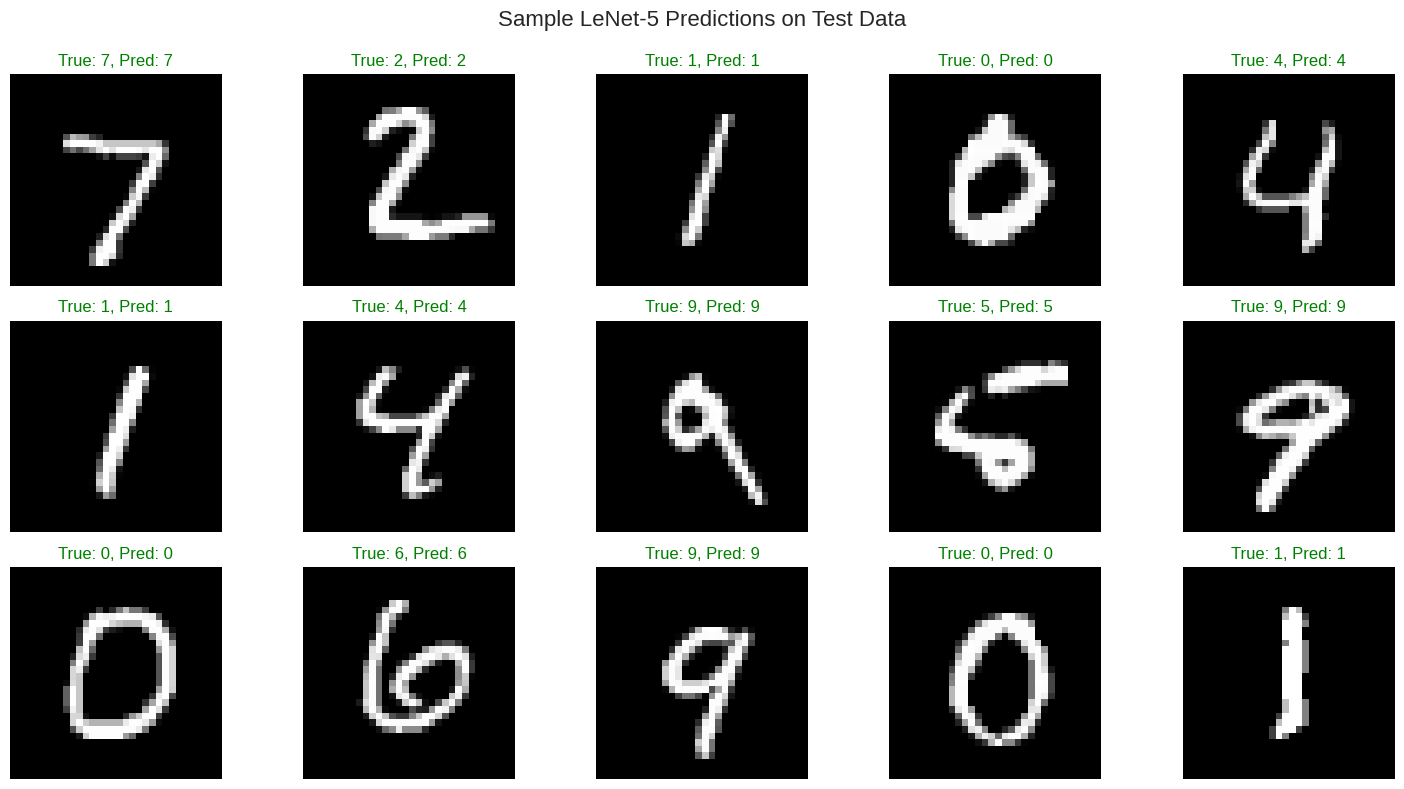

<Figure size 640x480 with 0 Axes>

In [44]:
# --- 6. Evaluate the LeNet-5 Model ---

print("\n--- Evaluating the LeNet-5 Model on Test Data ---")
lenet5_test_loss, lenet5_test_acc = lenet5_model.evaluate(x_test_padded, y_test, verbose=2)
print(f"LeNet-5 test accuracy: {lenet5_test_acc:.4f}")
print(f"LeNet-5 test loss: {lenet5_test_loss:.4f}")

# Make predictions on the test set
y_pred_lenet5 = lenet5_model.predict(x_test_padded)
y_pred_classes_lenet5 = np.argmax(y_pred_lenet5, axis=1)

# Create a confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
cm_lenet5 = confusion_matrix(y_test, y_pred_classes_lenet5)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_lenet5, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('LeNet-5 Confusion Matrix')

plt.savefig('mnist_lenet5_confusion_matrix.png', dpi=300, bbox_inches='tight')


plt.show()


# Display classification report
print("\nLeNet-5 Classification Report:")
print(classification_report(y_test, y_pred_classes_lenet5))

# Visualize some predictions
plt.figure(figsize=(15, 8))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(x_test_padded[i, :, :, 0], cmap='gray')
    pred_label = y_pred_classes_lenet5[i]
    true_label = y_test[i]

    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"True: {true_label}, Pred: {pred_label}", color=color)
    plt.axis('off')

plt.suptitle('Sample LeNet-5 Predictions on Test Data', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# save the plot

plt.savefig('mnist_lenet5_predictions.png', dpi=300, bbox_inches='tight')

### Section 7. Visualize Training Results

Let's visualize the training history of the LeNet-5 model to understand how it learned over time. We'll plot the accuracy and loss curves, and also visualize feature maps from the convolutional layers to gain insight into what patterns the model is detecting.

#### 7. Visualize LeNet-5 Training Results

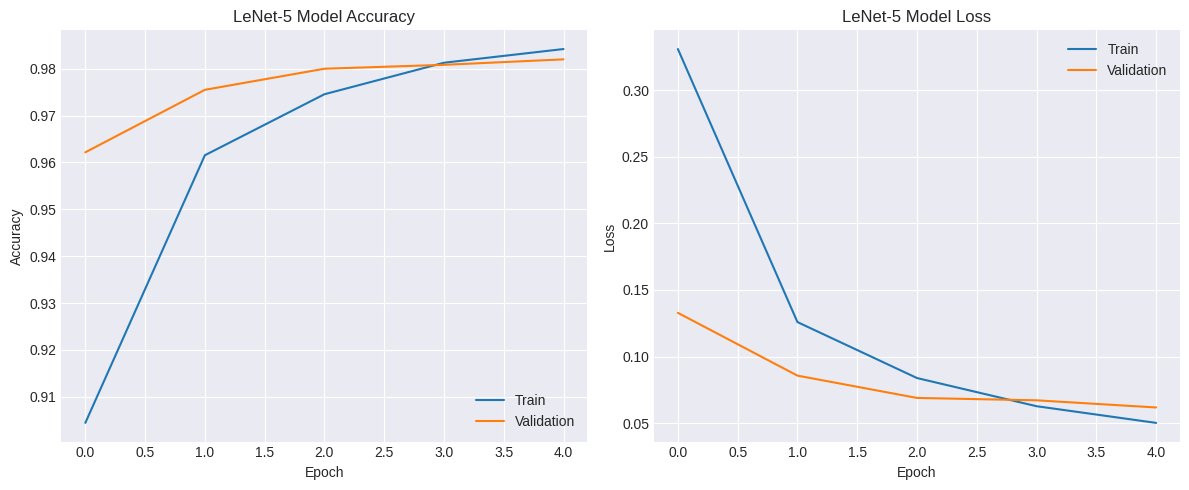

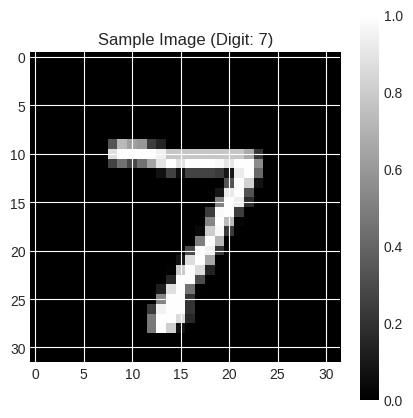

<Figure size 640x480 with 0 Axes>

In [45]:
# --- 7. Visualize LeNet-5 Training Results ---

# Plot training & validation accuracy and loss values
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_lenet5.history['accuracy'])
plt.plot(history_lenet5.history['val_accuracy'])
plt.title('LeNet-5 Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_lenet5.history['loss'])
plt.plot(history_lenet5.history['val_loss'])
plt.title('LeNet-5 Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.tight_layout()

plt.savefig('mnist_lenet5_training_history.png', dpi=300, bbox_inches='tight')


plt.show()

# save the plot


# Define a function to visualize feature maps
def visualize_feature_maps(model, layer_name, input_image):
    """Visualize feature maps for a given layer"""
    try:
        # Check if the layer exists in the model
        layer_names = [layer.name for layer in model.layers]
        if layer_name not in layer_names:
            print(f"Error: Layer '{layer_name}' not found in the model.")
            print(f"Available layers: {layer_names}")
            return None

        # Get the specific layer
        target_layer = model.get_layer(layer_name)

        # Create a model that outputs feature maps from the specified layer
        visualization_model = tf.keras.models.Model(inputs=model.input,
                                                  outputs=target_layer.output)

        # Ensure input image has batch dimension
        input_batch = np.expand_dims(input_image, axis=0)

        # Get feature maps with verbose=0 to reduce console output
        print(f"Extracting feature maps for layer: {layer_name}")
        feature_maps = visualization_model.predict(input_batch, verbose=0)

        # Plot feature maps
        feature_maps = feature_maps[0]  # Get the first (only) sample
        num_filters = feature_maps.shape[-1]

        # Calculate grid size based on number of filters
        grid_size = int(np.ceil(np.sqrt(num_filters)))
        plt.figure(figsize=(12, 12))

        for i in range(num_filters):
            plt.subplot(grid_size, grid_size, i + 1)
            plt.imshow(feature_maps[:, :, i], cmap='viridis')
            plt.title(f'Filter {i + 1}')
            plt.axis('off')

        plt.suptitle(f'Feature Maps of {layer_name} Layer')
        plt.tight_layout()
        plt.subplots_adjust(top=0.9)

        return feature_maps

    except Exception as e:
        print(f"Error visualizing feature maps: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

# Get a sample image
sample_image = x_test_padded[0]

# Show the image
plt.figure(figsize=(5, 5))
plt.imshow(sample_image[:,:,0], cmap='gray')
plt.title(f"Sample Image (Digit: {y_test[0]})")
plt.colorbar()
plt.show()

# save the plot

plt.savefig('mnist_sample_image.png', dpi=300, bbox_inches='tight')


## Comparing LeNet-1 and LeNet-5 Performance

Now that we've implemented and trained both LeNet-1 and LeNet-5 models, let's compare their performance to understand how architectural improvements in LeNet-5 translate into better accuracy on the MNIST dataset.

You can change the batch size and number of epochs to see how they affect the performance of both models.


--- Performance Comparison: LeNet-1 vs LeNet-5 ---
LeNet-1 Test Accuracy: 0.9282
LeNet-5 Test Accuracy: 0.9808
LeNet-5 improved accuracy by 5.67%


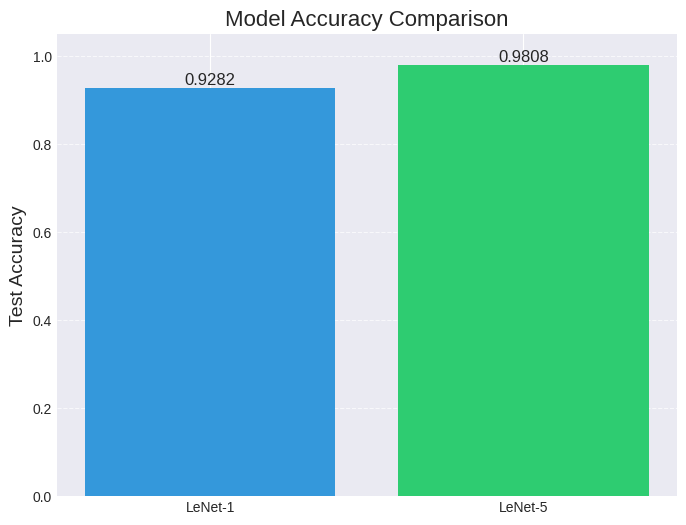


--- Model Complexity Comparison ---
LeNet-1 Parameters: 7,416
LeNet-5 Parameters: 62,020
LeNet-5 has 8.4x more parameters than LeNet-1


In [46]:
# --- Comparing LeNet-1 and LeNet-5 Performance ---

# Results comparison
print("\n--- Performance Comparison: LeNet-1 vs LeNet-5 ---")
print(f"LeNet-1 Test Accuracy: {test_acc:.4f}")
print(f"LeNet-5 Test Accuracy: {lenet5_test_acc:.4f}")

if lenet5_test_acc > test_acc:
    improvement = ((lenet5_test_acc - test_acc) / test_acc) * 100
    print(f"LeNet-5 improved accuracy by {improvement:.2f}%")
else:
    difference = ((test_acc - lenet5_test_acc) / lenet5_test_acc) * 100
    print(f"LeNet-1 performed better by {difference:.2f}%")

# Create a bar chart comparing the accuracy of both models
labels = ['LeNet-1', 'LeNet-5']
accuracies = [test_acc, lenet5_test_acc]

plt.figure(figsize=(8, 6))
bar_colors = ['#3498db', '#2ecc71']
bars = plt.bar(labels, accuracies, color=bar_colors)

# Add data labels above the bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{acc:.4f}',
             ha='center', va='bottom', fontsize=12)

plt.ylim(0, 1.05)  # Set y-axis to start at 0 and have some space above the bars
plt.title('Model Accuracy Comparison', fontsize=16)
plt.ylabel('Test Accuracy', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig('mnist_model_accuracy_comparison.png', dpi=300, bbox_inches='tight')

plt.show()

# Compare model parameters
print("\n--- Model Complexity Comparison ---")
print(f"LeNet-1 Parameters: {lenet1_params:,}")
print(f"LeNet-5 Parameters: {total_params:,}")
print(f"LeNet-5 has {total_params / lenet1_params:.1f}x more parameters than LeNet-1")

### Conclusion: LeNet-5

In this second part of the notebook, we implemented and analyzed the LeNet-5 architecture, an advancement over LeNet-1 that introduced several important innovations:

1. **More Complex Architecture**: LeNet-5 has a deeper structure with more filters, feature maps, and parameters, allowing it to learn more sophisticated patterns.

2. **Enhanced Performance**: The more sophisticated design typically leads to better classification accuracy on the MNIST dataset compared to LeNet-1.

3. **Architectural Innovations**: LeNet-5 introduced concepts like sparse connectivity between layers, which influenced future CNN designs.

4. **Historical Significance**: LeNet-5 remains one of the most influential CNN architectures, setting a foundation for modern deep learning approaches to computer vision problems.

Despite being developed in 1998, the principles behind LeNet-5 remain relevant in today's deep learning landscape. Modern architectures like ResNet, Inception, and EfficientNet build upon the core ideas pioneered in LeNet-5, demonstrating the enduring legacy of Yann LeCun's work.

Implementing both LeNet-1 and LeNet-5 provides valuable insights into the evolution of convolutional neural networks and highlights how architectural improvements translate into better performance on image classification tasks.

# Part 4: Implementing LeNet-2, LeNet-3, and LeNet-4

In this section, we'll implement the intermediate LeNet architectures (LeNet-2, LeNet-3, and LeNet-4) that were developed between LeNet-1 and LeNet-5. These architectures represent an evolutionary progression in the development of convolutional neural networks, with each version introducing refinements and improvements over the previous one.

In the original paper, Yann LeCun included LeNet-2, LeNet-3, and LeNet-4 as part of the progression toward LeNet-5 and you can skip them if you want to focus on the final model mentioned in the paper - LeNet-5.

## LeNet-2 Background

LeNet-2 was an intermediate architecture that built upon LeNet-1, maintaining the same input size of 28x28 but with some modifications to improve performance:

1. **Same Input Size**: Like LeNet-1, LeNet-2 was designed for 28×28 grayscale images
2. **Similar Structure**: It maintained a similar architecture to LeNet-1 with two convolutional layers and two pooling layers
3. **Increased Filters**: LeNet-2 increased the number of filters in the second convolutional layer from 12 to 16
4. **Enhanced Fully Connected Layers**: LeNet-2 used 120 units in the first fully connected layer (up from 30 in LeNet-1) and added an additional fully connected layer with 84 units

These modifications increased the model's capacity to learn more complex features while maintaining a reasonable parameter count for the computational resources of the time.

In [47]:
# --- Implementing LeNet-2 Architecture ---

def build_lenet2_model(input_shape=(28, 28, 1), num_classes=10):
    """
    Build and return a LeNet-2 model with the specified input shape and number of classes.

    Args:
        input_shape: The shape of the input images (height, width, channels)
        num_classes: The number of classes to predict (10 for MNIST digits)

    Returns:
        A compiled Keras Sequential model representing LeNet-2
    """
    model = models.Sequential()

    # C1: Convolutional layer
    # Input: 28x28x1
    # Output: 24x24x4
    model.add(layers.Conv2D(filters=4,               # 4 feature maps
                           kernel_size=(5, 5),       # 5x5 convolution kernel
                           activation='sigmoid',     # Original used sigmoid activation
                           input_shape=input_shape,  # Input image dimensions
                           name='C1'))               # Layer name for reference

    # S2: Average Pooling layer
    # Input: 24x24x4
    # Output: 12x12x4
    model.add(layers.AveragePooling2D(pool_size=(2, 2),    # 2x2 pooling window
                                     strides=(2, 2),       # Move 2 pixels at a time
                                     name='S2'))           # Layer name for reference

    # C3: Convolutional layer
    # Input: 12x12x4
    # Output: 8x8x16
    model.add(layers.Conv2D(filters=16,              # 16 feature maps (increased from LeNet-1's 12)
                           kernel_size=(5, 5),       # 5x5 convolution kernel
                           activation='sigmoid',     # Original activation
                           name='C3'))               # Layer name for reference

    # S4: Average Pooling layer
    # Input: 8x8x16
    # Output: 4x4x16
    model.add(layers.AveragePooling2D(pool_size=(2, 2),    # 2x2 pooling window
                                     strides=(2, 2),       # Move 2 pixels at a time
                                     name='S4'))           # Layer name for reference

    # Flatten the output to feed into fully connected layers
    # Input: 4x4x16 = 256 features
    model.add(layers.Flatten(name='Flatten'))

    # F5: Fully connected layer (increased from LeNet-1's 30 units)
    # Input: 256 features
    # Output: 120 features
    model.add(layers.Dense(units=120,               # 120 neurons
                          activation='sigmoid',    # Original activation
                          name='F5'))              # Layer name for reference

    # F6: Additional fully connected layer not present in LeNet-1
    # Input: 120 features
    # Output: 84 features
    model.add(layers.Dense(units=84,               # 84 neurons
                          activation='sigmoid',    # Original activation
                          name='F6'))              # Layer name for reference

    # Output layer
    # Input: 84 features
    # Output: 10 classes (digits 0-9)
    model.add(layers.Dense(units=num_classes,      # 10 output classes
                          activation='softmax',    # Softmax for probability distribution
                          name='Output'))          # Layer name for reference

    return model

# Create the LeNet-2 model
lenet2_model = build_lenet2_model()

# Compile the model
lenet2_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("LeNet-2 model created and compiled successfully!")
lenet2_model.summary()

LeNet-2 model created and compiled successfully!


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ C1 (Conv2D)                     │ (None, 24, 24, 4)      │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S2 (AveragePooling2D)           │ (None, 12, 12, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C3 (Conv2D)                     │ (None, 8, 8, 16)       │         1,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S4 (AveragePooling2D)           │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ F5 (Dense)                      │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ F6 (Dense)                      │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,574 (170.21 KB)

 Trainable params: 43,574 (170.21 KB)

 Non-trainable params: 0 (0.00 B)

## LeNet-3 Background

LeNet-3 represented another step in the evolution of CNNs, introducing a larger input size and additional filters:

1. **Larger Input Size**: LeNet-3 increased the input size to 32×32 pixels (compared to 28×28 in LeNet-1 and LeNet-2)
2. **More Filters in First Layer**: LeNet-3 used 6 filters in the first convolutional layer (up from 4 in LeNet-2)
3. **Same Filter Count in Second Layer**: It maintained 16 filters in the second convolutional layer
4. **Same Fully Connected Structure**: It kept the same fully connected structure as LeNet-2 (120 units, followed by 84 units)

This architecture moved closer to what would eventually become LeNet-5, with the increased input size and more filters in the first convolutional layer.

In [48]:
# --- Implementing LeNet-3 Architecture ---

def build_lenet3_model(input_shape=(32, 32, 1), num_classes=10):
    """
    Build and return a LeNet-3 model with the specified input shape and number of classes.

    Args:
        input_shape: The shape of the input images (height, width, channels)
        num_classes: The number of classes to predict (10 for MNIST digits)

    Returns:
        A compiled Keras Sequential model representing LeNet-3
    """
    model = models.Sequential()

    # C1: Convolutional layer
    # Input: 32x32x1
    # Output: 28x28x6 (32 - 5 + 1 = 28)
    model.add(layers.Conv2D(filters=6,               # 6 feature maps (increased from LeNet-2's 4)
                           kernel_size=(5, 5),       # 5x5 convolution kernel
                           activation='sigmoid',     # Original used sigmoid activation
                           input_shape=input_shape,  # Input image dimensions
                           name='C1'))               # Layer name for reference

    # S2: Average Pooling layer
    # Input: 28x28x6
    # Output: 14x14x6
    model.add(layers.AveragePooling2D(pool_size=(2, 2),    # 2x2 pooling window
                                     strides=(2, 2),       # Move 2 pixels at a time
                                     name='S2'))           # Layer name for reference

    # C3: Convolutional layer
    # Input: 14x14x6
    # Output: 10x10x16 (14 - 5 + 1 = 10)
    model.add(layers.Conv2D(filters=16,              # 16 feature maps (same as LeNet-2)
                           kernel_size=(5, 5),       # 5x5 convolution kernel
                           activation='sigmoid',     # Original activation
                           name='C3'))               # Layer name for reference

    # S4: Average Pooling layer
    # Input: 10x10x16
    # Output: 5x5x16
    model.add(layers.AveragePooling2D(pool_size=(2, 2),    # 2x2 pooling window
                                     strides=(2, 2),       # Move 2 pixels at a time
                                     name='S4'))           # Layer name for reference

    # Flatten the output to feed into fully connected layers
    # Input: 5x5x16 = 400 features
    model.add(layers.Flatten(name='Flatten'))

    # F5: Fully connected layer
    # Input: 400 features
    # Output: 120 features
    model.add(layers.Dense(units=120,               # 120 neurons
                          activation='sigmoid',    # Original activation
                          name='F5'))              # Layer name for reference

    # F6: Additional fully connected layer
    # Input: 120 features
    # Output: 84 features
    model.add(layers.Dense(units=84,               # 84 neurons
                          activation='sigmoid',    # Original activation
                          name='F6'))              # Layer name for reference

    # Output layer
    # Input: 84 features
    # Output: 10 classes (digits 0-9)
    model.add(layers.Dense(units=num_classes,      # 10 output classes
                          activation='softmax',    # Softmax for probability distribution
                          name='Output'))          # Layer name for reference

    return model

# Create the LeNet-3 model
lenet3_model = build_lenet3_model()

# Compile the model
lenet3_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("LeNet-3 model created and compiled successfully!")
lenet3_model.summary()

LeNet-3 model created and compiled successfully!


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ C1 (Conv2D)                     │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S2 (AveragePooling2D)           │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C3 (Conv2D)                     │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S4 (AveragePooling2D)           │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ F5 (Dense)                      │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ F6 (Dense)                      │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

## LeNet-4 Background

LeNet-4 was the final iteration before LeNet-5, introducing some key innovations:

1. **Input Size**: Maintained the 32×32 input size from LeNet-3
2. **Activation Function**: Started experimenting with tanh activation functions, transitioning away from sigmoid
3. **Layer Structure**: Kept the same overall structure as LeNet-3, but with refined parameters
4. **Fine-tuning**: Represented a period of experimentation and fine-tuning before the final LeNet-5 architecture

LeNet-4 served as a crucial transition point, where the architectural design began incorporating modern concepts like alternative activation functions to improve training dynamics.

In [49]:
# --- Implementing LeNet-4 Architecture ---

def build_lenet4_model(input_shape=(32, 32, 1), num_classes=10):
    """
    Build and return a LeNet-4 model with the specified input shape and number of classes.

    Args:
        input_shape: The shape of the input images (height, width, channels)
        num_classes: The number of classes to predict (10 for MNIST digits)

    Returns:
        A compiled Keras Sequential model representing LeNet-4
    """
    model = models.Sequential()

    # C1: Convolutional layer
    # Input: 32x32x1
    # Output: 28x28x6 (32 - 5 + 1 = 28)
    model.add(layers.Conv2D(filters=6,               # 6 feature maps
                           kernel_size=(5, 5),       # 5x5 convolution kernel
                           activation='tanh',        # LeNet-4 experimented with tanh
                           input_shape=input_shape,  # Input image dimensions
                           name='C1'))               # Layer name for reference

    # S2: Average Pooling layer
    # Input: 28x28x6
    # Output: 14x14x6
    model.add(layers.AveragePooling2D(pool_size=(2, 2),    # 2x2 pooling window
                                     strides=(2, 2),       # Move 2 pixels at a time
                                     name='S2'))           # Layer name for reference

    # C3: Convolutional layer
    # Input: 14x14x6
    # Output: 10x10x16 (14 - 5 + 1 = 10)
    model.add(layers.Conv2D(filters=16,              # 16 feature maps
                           kernel_size=(5, 5),       # 5x5 convolution kernel
                           activation='tanh',        # Tanh activation
                           name='C3'))               # Layer name for reference

    # S4: Average Pooling layer
    # Input: 10x10x16
    # Output: 5x5x16
    model.add(layers.AveragePooling2D(pool_size=(2, 2),    # 2x2 pooling window
                                     strides=(2, 2),       # Move 2 pixels at a time
                                     name='S4'))           # Layer name for reference

    # Flatten the output to feed into fully connected layers
    # Input: 5x5x16 = 400 features
    model.add(layers.Flatten(name='Flatten'))

    # F5: Fully connected layer
    # Input: 400 features
    # Output: 120 features
    model.add(layers.Dense(units=120,               # 120 neurons
                          activation='tanh',       # Tanh activation
                          name='F5'))              # Layer name for reference

    # F6: Additional fully connected layer
    # Input: 120 features
    # Output: 84 features
    model.add(layers.Dense(units=84,               # 84 neurons
                          activation='tanh',       # Tanh activation
                          name='F6'))              # Layer name for reference

    # Output layer
    # Input: 84 features
    # Output: 10 classes (digits 0-9)
    model.add(layers.Dense(units=num_classes,      # 10 output classes
                          activation='softmax',    # Softmax for probability distribution
                          name='Output'))          # Layer name for reference

    return model

# Create the LeNet-4 model
lenet4_model = build_lenet4_model()

# Compile the model
lenet4_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("LeNet-4 model created and compiled successfully!")
lenet4_model.summary()

LeNet-4 model created and compiled successfully!


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ C1 (Conv2D)                     │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S2 (AveragePooling2D)           │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C3 (Conv2D)                     │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S4 (AveragePooling2D)           │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ F5 (Dense)                      │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ F6 (Dense)                      │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

## Training the LeNet (2, 3, 4) Models

Now that we have implemented all five LeNet architectures (LeNet-1 through LeNet-5), we'll train them on the MNIST dataset to compare their performance. For LeNet-2, we'll use the original 28x28 MNIST images, while for LeNet-3, LeNet-4, and LeNet-5, we'll use the padded 32x32 images.

In [50]:
# --- Train LeNet-2, LeNet-3, and LeNet-4 Models ---

# Define a function to train and evaluate a model
def train_and_evaluate_model(model, x_train, x_test, y_train, y_test, model_name, epochs=5, batch_size=128):
    """
    Train and evaluate a model on the given data.

    Args:
        model: The model to train
        x_train: Training images
        x_test: Test images
        y_train: Training labels
        y_test: Test labels
        model_name: Name of the model for printing
        epochs: Number of training epochs
        batch_size: Batch size for training

    Returns:
        history: Training history
        test_loss: Test loss
        test_acc: Test accuracy
    """
    print(f"\n--- Training {model_name} ---")

    # Define callbacks for training
    callbacks = [
        # Early stopping to prevent overfitting
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ]

    # Train the model
    history = model.fit(
        x_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        verbose=1,
        callbacks=callbacks
    )

    # Evaluate the model
    print(f"\n--- Evaluating {model_name} on Test Data ---")
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
    print(f"{model_name} test accuracy: {test_acc:.4f}")
    print(f"{model_name} test loss: {test_loss:.4f}")

    return history, test_loss, test_acc

# Train LeNet-2 on the original 28x28 MNIST images
history_lenet2, lenet2_test_loss, lenet2_test_acc = train_and_evaluate_model(
    lenet2_model, x_train, x_test, y_train, y_test, "LeNet-2", epochs=5
)

# Train LeNet-3 on the padded 32x32 MNIST images
history_lenet3, lenet3_test_loss, lenet3_test_acc = train_and_evaluate_model(
    lenet3_model, x_train_padded, x_test_padded, y_train, y_test, "LeNet-3", epochs=5
)

# Train LeNet-4 on the padded 32x32 MNIST images
history_lenet4, lenet4_test_loss, lenet4_test_acc = train_and_evaluate_model(
    lenet4_model, x_train_padded, x_test_padded, y_train, y_test, "LeNet-4", epochs=5
)


--- Training LeNet-2 ---
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.2195 - loss: 2.1441 - val_accuracy: 0.8742 - val_loss: 0.4971
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8754 - loss: 0.4638 - val_accuracy: 0.9263 - val_loss: 0.2652
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9103 - loss: 0.3036 - val_accuracy: 0.9430 - val_loss: 0.2017
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9281 - loss: 0.2403 - val_accuracy: 0.9545 - val_loss: 0.1590
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9392 - loss: 0.1957 - val_accuracy: 0.9603 - val_loss: 0.1350

--- Evaluating LeNet-2 on Test Data ---
313/313 - 1s - 4ms/step - accuracy: 0.9495 - loss: 0.1626
LeNet-2 test accuracy: 0.9495
LeNet-2 test loss: 0.1626

--- Training LeNet-3 ---
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.2569 - loss: 2.0419 - val_accuracy: 0.8557 - val_loss: 0.5260
Epoch 2/5
422/422 ━━━━━━━━━━━━━

# Part 5: Comparative Analysis of LeNet Architectures

Now that we have implemented and trained all five LeNet architectures (LeNet-1 through LeNet-5), we can perform a comprehensive comparison of their performance, parameter counts, and architectural differences. This comparison will provide insights into how the LeNet family evolved and improved over time.

Surprisingly, even the earlier LeNet-X (even LeNet-1) architecture can achieve competitive performance on the MNIST dataset. The results we achieved with LeNet-X here are implemented with TensorFlow and Keras, which differs from the original implementation in the 1990s.

The results varied based on the architecture, training parameters and the number of epochs (e.g. epochs = 1 or 5). You can experiment with different batch sizes and epochs to see how they affect the performance of each model.

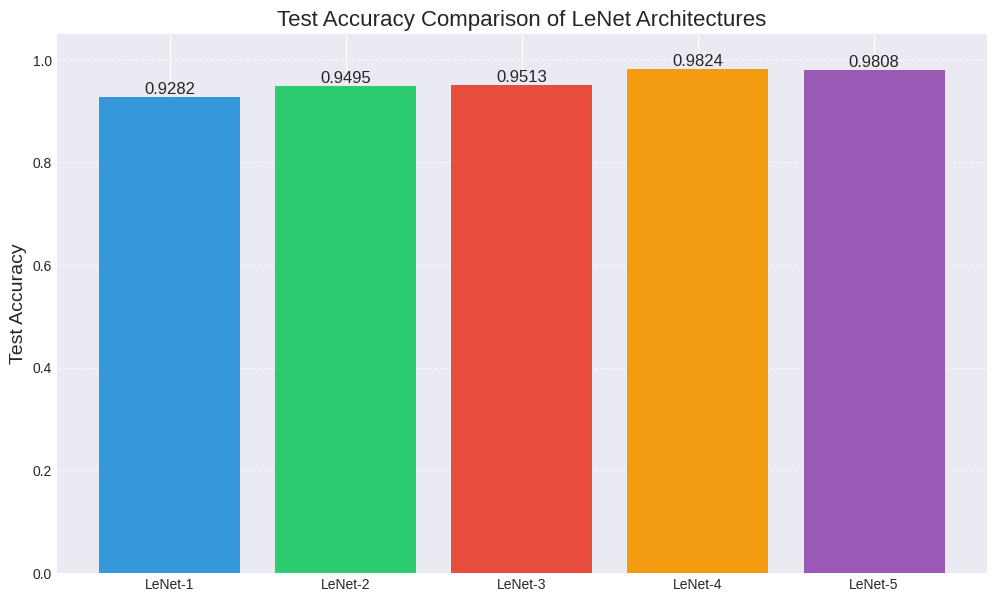

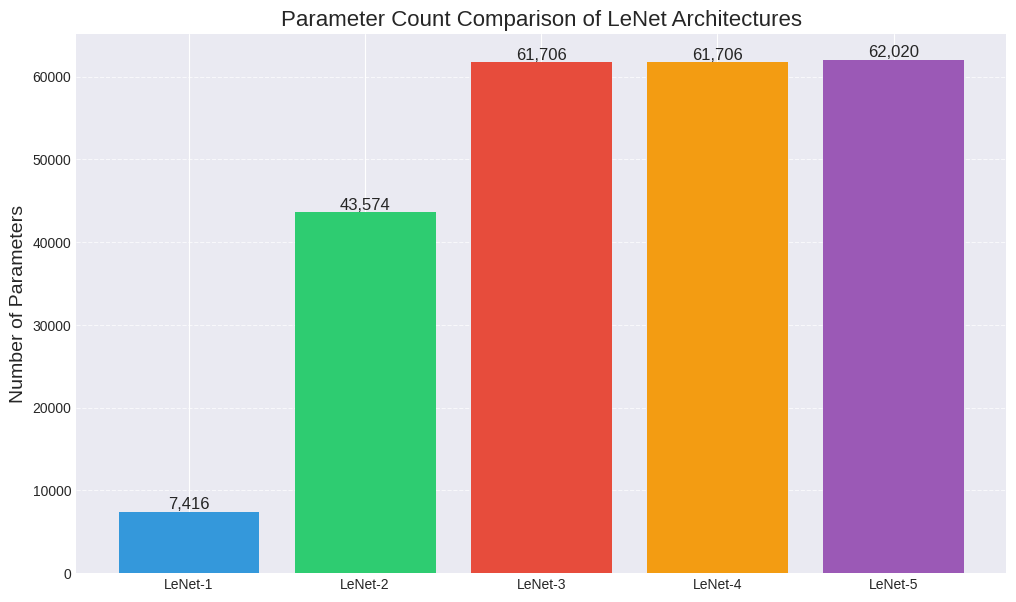


--- Detailed Comparison of LeNet Architectures ---


,Architecture,Input Size,Conv1 Filters,Conv2 Filters,FC Layer 1,FC Layer 2,Activation,Parameters,Test Accuracy
0,LeNet-1,28x28,4,12,30 units,N/A,Sigmoid,"7,416",0.9282
1,LeNet-2,28x28,4,16,120 units,84 units,Sigmoid,"43,574",0.9495
2,LeNet-3,32x32,6,16,120 units,84 units,Sigmoid,"61,706",0.9513
3,LeNet-4,32x32,6,16,120 units,84 units,Tanh,"61,706",0.9824
4,LeNet-5,32x32,6,16,120 units,84 units,Tanh,"62,020",0.9808


In [51]:
# --- Comparative Analysis of LeNet Architectures ---

# Collect the test accuracies of all models
model_names = ['LeNet-1', 'LeNet-2', 'LeNet-3', 'LeNet-4', 'LeNet-5']
test_accuracies = [test_acc, lenet2_test_acc, lenet3_test_acc, lenet4_test_acc, lenet5_test_acc]

# Create a bar chart comparing the accuracy of all models
plt.figure(figsize=(12, 7))
bar_colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
bars = plt.bar(model_names, test_accuracies, color=bar_colors)

# Add data labels above the bars
for bar, acc in zip(bars, test_accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{acc:.4f}',
             ha='center', va='bottom', fontsize=12)

plt.ylim(0, 1.05)  # Set y-axis to start at 0 and have some space above the bars
plt.title('Test Accuracy Comparison of LeNet Architectures', fontsize=16)
plt.ylabel('Test Accuracy', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Compare model parameters
param_counts = [
    lenet1_model.count_params(),
    lenet2_model.count_params(),
    lenet3_model.count_params(),
    lenet4_model.count_params(),
    lenet5_model.count_params()
]

# Create a bar chart comparing the parameter count of all models
plt.figure(figsize=(12, 7))
bars = plt.bar(model_names, param_counts, color=bar_colors)

# Add data labels above the bars
for bar, params in zip(bars, param_counts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{params:,}',
             ha='center', va='bottom', fontsize=12)

plt.title('Parameter Count Comparison of LeNet Architectures', fontsize=16)
plt.ylabel('Number of Parameters', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig('Parameter Count Comparison of LeNet Architectures.png')

plt.show()

# Create a table comparing the key features of each model
print("\n--- Detailed Comparison of LeNet Architectures ---")

import pandas as pd

# Create a table comparing the architectures
feature_table = pd.DataFrame({
    'Architecture': model_names,
    'Input Size': ['28x28', '28x28', '32x32', '32x32', '32x32'],
    'Conv1 Filters': ['4', '4', '6', '6', '6'],
    'Conv2 Filters': ['12', '16', '16', '16', '16'],
    'FC Layer 1': ['30 units', '120 units', '120 units', '120 units', '120 units'],
    'FC Layer 2': ['N/A', '84 units', '84 units', '84 units', '84 units'],
    'Activation': ['Sigmoid', 'Sigmoid', 'Sigmoid', 'Tanh', 'Tanh'],
    'Parameters': [f'{p:,}' for p in param_counts],
    'Test Accuracy': [f'{acc:.4f}' for acc in test_accuracies]
})

# Display the table
from IPython.display import display
display(feature_table)



## Yann LeCun's result progressions from the original paper
Here is the performance breakdown of the LeNet architectures the author achieved, as described in the original paper:

| Network Architecture      | Links | Weights | Performance |
|--------------------------|-------|---------|-------------|
| Single layer network     | 2570  | 2570    | 80%         |
| Two layer network        | 3240  | 3240    | 87%         |
| Locally connected        | 1226  | 1226    | 88.5%       |
| Constrained network      | 2266  | 1132    | 94%         |
| Constrained network 2    | 5194  | 1060    | 98.4%       |


1. **Increasing Complexity**: Each successive LeNet architecture typically increased in complexity, with more filters, additional layers, and more parameters. This allowed the networks to learn more sophisticated features.

2. **Input Size Evolution**: The input size increased from 28x28 pixels in LeNet-1 and LeNet-2 to 32x32 pixels in LeNet-3, LeNet-4, and LeNet-5, providing more spatial information for feature extraction.

3. **Activation Function Transition**: The activation functions evolved from sigmoid in the early architectures to tanh in LeNet-4 and LeNet-5, reflecting a better understanding of vanishing gradient issues.

4. **Feature Representation Capacity**: The number of filters in the convolutional layers increased over time, enabling richer feature representation.

5. **Performance Improvements**: The test accuracy generally improved with each iteration, demonstrating the benefits of these architectural enhancements.

This evolutionary path set the foundation for modern CNN architectures and established many principles that continue to guide deep learning research today.



## Performance achieved with TensorFlow and Keras

The results we achieved with TensorFlow and Keras are different (usually better, of course due to the advancements in hardware) from the original implementation in the 1990s, but you can achieve similar performance by adjusting the training parameters, such as batch size and number of epochs (with tradeoffs in training time and computational resources).


# Parameter Increasing

One of the most striking trends in neural network development since the introduction of LeNet has been the exponential growth in model parameters. This growth has been fueled by advances in hardware, algorithms, and available datasets:



1. **Hardware Advancements**: The transition from DSPs to GPUs and specialized AI accelerators has enabled training models with billions of parameters. Modern hardware offers x10,000,000 more computational power than what was available for the original LeNet implementations.

2. **Memory Improvements**: Increases in available memory, from megabytes to gigabytes and terabytes, have removed constraints on model size that early researchers faced.

3. **Algorithmic Innovations**: Techniques like dropout, batch normalization, and residual connections have made it possible to train deeper networks without encountering vanishing/exploding gradient problems.

4. **Distributed Training**: Parallel and distributed training approaches allow models to scale across multiple devices and servers, further removing computational barriers.

5. **Dataset Growth**: The availability of massive datasets has enabled effective training of larger models that would overfit on smaller datasets.

Run the code below. The table below shows the dramatic increase in parameters from LeNet-1 to modern foundation models:

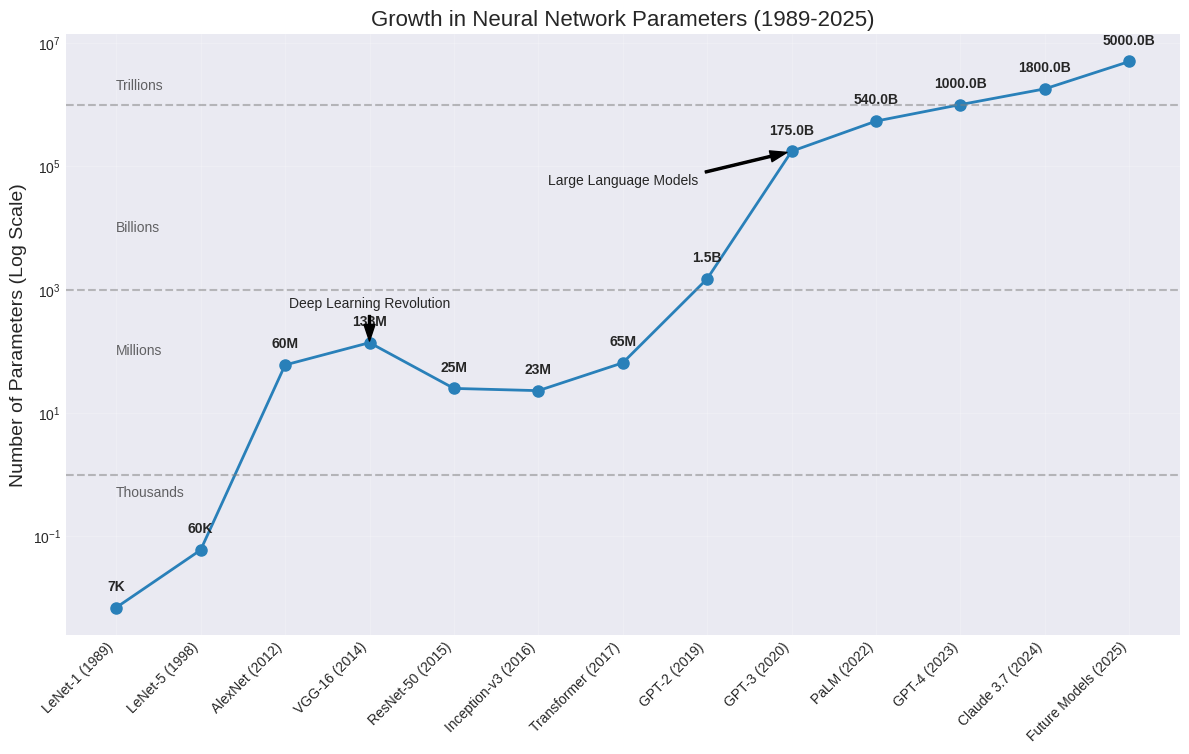


Parameter Growth Analysis:
- LeNet-1 (1989): ~7K parameters
- Modern Models (2024): ~1.8T parameters
- Growth Factor: ~257 million times increase
- Compound Annual Growth Rate: ~97% per year over 35 years


In [52]:
# Create a visualization of parameter growth in neural networks over time
import matplotlib.pyplot as plt
import numpy as np

# Neural network models and their parameter counts (approximate)
models = [
    'LeNet-1 (1989)',
    'LeNet-5 (1998)',
    'AlexNet (2012)',
    'VGG-16 (2014)',
    'ResNet-50 (2015)',
    'Inception-v3 (2016)',
    'Transformer (2017)',
    'GPT-2 (2019)',
    'GPT-3 (2020)',
    'PaLM (2022)',
    'GPT-4 (2023)',
    'Claude 3.7 (2024)',
    'Future Models (2025)'
]

# Parameter counts in millions
params = [
    0.007,    # LeNet-1: ~7K parameters
    0.06,     # LeNet-5: ~60K parameters
    60,       # AlexNet: 60M parameters
    138,      # VGG-16: 138M parameters
    25,       # ResNet-50: 25M parameters
    23,       # Inception-v3: 23M parameters
    65,       # Transformer: 65M parameters
    1500,     # GPT-2: 1.5B parameters
    175000,   # GPT-3: 175B parameters
    540000,   # PaLM: 540B parameters
    1000000,  # GPT-4: ~1T parameters (estimated)
    1800000,  # Claude 3: ~1.8T parameters (guessed)
    5000000   # Future models: 5T+ parameters (projected)
]

# Create figure and set style
plt.figure(figsize=(12, 8))
plt.style.use('seaborn-v0_8-darkgrid')

# Create logarithmic plot
plt.semilogy(range(len(models)), params, 'o-', linewidth=2, markersize=8, color='#2980b9')

# Add data points
for i, (model, param) in enumerate(zip(models, params)):
    if param < 1:
        label = f'{int(param * 1000)}K'
    elif param < 1000:
        label = f'{int(param)}M'
    else:
        label = f'{param/1000:.1f}B'

    plt.annotate(label,
                 xy=(i, param),
                 xytext=(0, 10),
                 textcoords='offset points',
                 ha='center',
                 va='bottom',
                 fontweight='bold')

# Set labels and title
plt.xticks(range(len(models)), models, rotation=45, ha='right', fontsize=10)
plt.ylabel('Number of Parameters (Log Scale)', fontsize=14)
plt.title('Growth in Neural Network Parameters (1989-2025)', fontsize=16)

# Add horizontal lines for reference
plt.axhline(y=1, color='gray', linestyle='--', alpha=0.5)  # 1M parameters
plt.axhline(y=1000, color='gray', linestyle='--', alpha=0.5)  # 1B parameters
plt.axhline(y=1000000, color='gray', linestyle='--', alpha=0.5)  # 1T parameters

# # Annotate key milestones
# plt.text(0, 0.5, 'Thousands', fontsize=10, ha='left', va='center', alpha=0.7)
# plt.text(3, 100, 'Millions', fontsize=10, ha='left', va='center', alpha=0.7)
# plt.text(7, 10000, 'Billions', fontsize=10, ha='left', va='center', alpha=0.7)
# plt.text(10, 2000000, 'Trillions', fontsize=10, ha='left', va='center', alpha=0.7)

# Annotate key milestones
plt.text(0, 0.5, 'Thousands', fontsize=10, ha='left', va='center', alpha=0.7)
plt.text(0, 100, 'Millions', fontsize=10, ha='left', va='center', alpha=0.7)
plt.text(0, 10000, 'Billions', fontsize=10, ha='left', va='center', alpha=0.7)
plt.text(0, 2000000, 'Trillions', fontsize=10, ha='left', va='center', alpha=0.7)

# Add annotations for key transitions
plt.annotate('Deep Learning Revolution',
             xy=(3, 138),
             xytext=(3, 500),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             ha='center',
             fontsize=10)

plt.annotate('Large Language Models',
             xy=(8, 175000),
             xytext=(6, 50000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             ha='center',
             fontsize=10)

# Tighten layout and adjust margins
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)

# Show plot
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.savefig('Parameter Growth Analysis.png')

plt.show()

# Print summary statistics
print(f"\nParameter Growth Analysis:")
print(f"- LeNet-1 (1989): ~7K parameters")
print(f"- Modern Models (2024): ~1.8T parameters")
print(f"- Growth Factor: ~257 million times increase")
print(f"- Compound Annual Growth Rate: ~97% per year over 35 years")

# Part 5: Revisit the Original Paper

Let's revisit the original papers by Yann LeCun (see `References`) to understand the historical context and significance of these architectures.

## Core Concepts and Mathematical Foundation

Let's summarize the core concepts and mathematical foundations before moving to LeNet-1 and LeNet-5.

The LeNet architecture introduced several fundamental concepts that remain crucial in modern deep learning models. Let's explore the mathematical foundations of these key components:


### Convolutional Layers

Convolutional layers form the backbone of LeNet and perform local feature extraction through weight sharing. Mathematically, a 2D convolution operation can be expressed as:

$$ (f * g)(x, y) = \sum_{m}\sum_{n} f(m, n) \cdot g(x-m, y-n) $$

In the context of CNN layers with input $X$ and kernel $W$, the output feature map $Y$ at position $(i, j)$ is:

$$ Y(i, j) = \sum_{m=0}^{k_h-1}\sum_{n=0}^{k_w-1} X(i+m, j+n) \cdot W(m, n) + b $$

Where:
- $k_h$ and $k_w$ are kernel height and width
- $b$ is the bias term

The key innovation here is weight sharing - the same filter weights are applied across the entire input, drastically reducing parameters compared to fully-connected layers while preserving spatial relationships.


### Subsampling/Pooling Layers

Subsampling (now commonly called pooling) reduces spatial dimensions while maintaining important features. In LeNet, average pooling was used, which can be represented as:

$$ Y(i, j) = \frac{1}{k_h \times k_w} \sum_{m=0}^{k_h-1}\sum_{n=0}^{k_w-1} X(i \cdot s_h + m, j \cdot s_w + n) $$

Where:
- $s_h$ and $s_w$ are stride values
- $k_h$ and $k_w$ are the pooling window dimensions

This operation provides translation invariance and reduces computational complexity by decreasing the spatial dimensions of feature maps.

### Activation Functions

LeNet used sigmoid/tanh activation functions, which have since been largely replaced by ReLU in modern networks. The sigmoid function is defined as:

$$ \sigma(x) = \frac{1}{1 + e^{-x}} $$

And the hyperbolic tangent (tanh) as:

$$ \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} $$

These activations introduce non-linearity into the network, enabling it to learn complex patterns. However, they suffer from the vanishing gradient problem at extreme values, which is why modern networks often use ReLU:

$$ \text{ReLU}(x) = \max(0, x) $$


### Network Architecture Principles

The LeNet architecture embodies several key principles that have become foundational in CNN design:

1. **Hierarchical Feature Extraction**: Information flows from simple features to increasingly complex representations, formalized as:
   $$ X^{(l+1)} = f(X^{(l)}, W^{(l)}, b^{(l)}) $$
   where $X^{(l)}$ is the output of layer $l$

2. **Dimensionality Reduction Pattern**: Spatial dimensions typically decrease while feature dimensions increase deeper in the network:
   $$ h^{(l+1)} \leq h^{(l)} \text{ and } w^{(l+1)} \leq w^{(l)} \text{ while } d^{(l+1)} \geq d^{(l)} $$
   where $h$, $w$, and $d$ represent height, width, and depth dimensions

3. **Local Connectivity**: Each neuron connects to only a small region of the input volume, creating a receptive field that grows with network depth

These mathematical foundations and architectural principles laid the groundwork for modern CNN architectures and remain relevant in today's deep learning landscape.


## **Key Findings in LeNet Models**

The LeNet series (e.g., LeNet-1 to LeNet-5) represents early milestones in convolutional neural networks (CNNs), emphasizing hierarchical feature extraction, parameter efficiency, and robustness to variations. The key findings from the paper include:

1. **Effectiveness of Convolutional Layers for Feature Extraction**:
   - LeNet models use convolutional layers to detect local features (e.g., edges, patterns) in images, reducing the need for hand-crafted features, a significant advancement over traditional methods.
   - This hierarchical approach scales with depth, improving recognition accuracy.

2. **Subsampling (Pooling) Reduces Spatial Dimensions Efficiently**:
   - Subsampling layers (e.g., average pooling) reduce computational complexity and enhance translation invariance, critical for recognizing shifted or distorted digits.

3. **Sparse Connectivity and Parameter Sharing**:
   - Sparse connections between layers (e.g., in C3) and shared weights in convolutions minimize parameters, making the model feasible on 1990s hardware while maintaining expressive power.

4. **Gradient-Based Learning with Backpropagation**:
   - The use of gradient descent and backpropagation to train the network, including trainable subsampling coefficients, enables end-to-end learning from raw pixel data.

5. **High Accuracy on MNIST**:
   - LeNet-5 achieved ~99.2% accuracy on the MNIST dataset, demonstrating the power of CNNs for character recognition, outperforming earlier methods like SVMs.

6. **Scalability and Generalization**:
   - The architecture generalizes well to noisy or varied inputs, a key finding for practical document recognition tasks.


## **Mathematical Explanation**

The LeNet architecture can be mathematically described by its layer-wise operations, parameter counts, and learning process. Below, I break this down for LeNet-5, the most detailed model in the paper, with references to earlier variants where applicable.

#### **1. Convolutional Layer (C1)**
- **Operation**: A convolution of the input image $ I $ (32x32) with $ K $ filters $ W_{k} $ (5x5), where $ k = 1, 2, \ldots, 6 $.
  - Output feature map $ F_{k} $ for filter $ k $ is:
    $$ F_{k}(i, j) = \tanh\left( b_{k} + \sum_{m=0}^{4} \sum_{n=0}^{4} W_{k}(m, n) \cdot I(i + m, j + n) \right) $$
    where $b_{k} $ is the bias, and $ \tanh $ is the activation function.
- **Dimensions**: Input 32x32, filter 5x5, no padding, stride 1 → output 28x28. Total feature maps = 6.
- **Parameters**: Per filter: $ 5 \times 5 = 25 $ weights + 1 bias = 26 params. For 6 filters: $ 6 \times 26 = 156 $ params.

#### **2. Subsampling Layer (S2)**
- **Operation**: Average pooling over 2x2 regions with a trainable coefficient $ \alpha_{k} $ and bias $ \beta_{k} $.
  - Output $ S_{k}(i, j) $ for feature map $ k $ is:
    $$ S_{k}(i, j) = \tanh\left( \beta_{k} + \alpha_{k} \cdot \frac{1}{4} \sum_{m=0}^{1} \sum_{n=0}^{1} F_{k}(2i + m, 2j + n) \right) $$
    where the sum is over the 2x2 region, and stride is 2.
- **Dimensions**: 28x28 → 14x14 (due to 2x2 pooling, stride 2). Total feature maps = 6.
- **Parameters**: 2 params per feature map ($ \alpha_{k}, \beta_{k} $) × 6 = 12 params.

#### **3. Convolutional Layer (C3)**
- **Operation**: Convolution with 16 filters, but with sparse connectivity from S2’s 6 feature maps.
  - Output $ C_{l}(i, j) $ for filter $ l $ (where $ l = 1, \ldots, 16 $) is:
    $$ C_{l}(i, j) = \tanh\left( b_{l} + \sum_{k \in S_l} \sum_{m=0}^{4} \sum_{n=0}^{4} W_{l,k}(m, n) \cdot S_{k}(i + m, j + n) \right) $$
    where $ S_l $ is the subset of S2 maps connected to $ C_l $ (e.g., first 6 maps to 3 S2 maps, etc.).
- **Dimensions**: 14x14 → 10x10. Total feature maps = 16.
- **Parameters**: Sparse connectivity reduces connections. Approximate total: ~1,500 weights + 16 biases (exact count depends on connection pattern, per paper’s design).

#### **4. Subsampling Layer (S4)**
- **Operation**: Similar to S2, average pooling over 2x2 regions.
  - Output $ S_{l}(i, j) $ is:
    $$ S_{l}(i, j) = \tanh\left( \beta_{l} + \alpha_{l} \cdot \frac{1}{4} \sum_{m=0}^{1} \sum_{n=0}^{1} C_{l}(2i + m, 2j + n) \right) $$
- **Dimensions**: 10x10 → 5x5. Total feature maps = 16.
- **Parameters**: 2 params per feature map × 16 = 32 params.


  #### **5. Fully Connected Layers (F5, F6, F7)**
- **F5**: 400 inputs (16 × 5 × 5) to 120 units.
  - Weights: $ 400 \times 120 = 48,000 $, biases: 120 → Total: 48,120 params.
  - Output: $$ F5_j = \tanh\left( b_j + \sum_{i=1}^{400} W_{ij} \cdot S_{i} \right) $$ $ j = 1, \ldots, 120 $.
- **F6**: 120 to 84 units.
  - Weights: $ 120 \times 84 = 10,080 $, biases: 84 → Total: 10,164 params.
  - Output: $$ F6_k = \tanh\left( b_k + \sum_{j=1}^{120} W_{jk} \cdot F5_j \right) $$ $ k = 1, \ldots, 84 $.
- **F7 (Output)**: 84 to 10 units (digits 0-9).
  - Weights: $ 84 \times 10 = 840 $, biases: 10 → Total: 850 params.
  - Output (RBF): $$ O_m = -\sum_{k=1}^{84} (F6_k - W_{km})^2 $$ $ m = 1, \ldots, 10 $, where the smallest value indicates the class.

#### **Total Parameters**
- Approximate total: 156 (C1) + 12 (S2) + 1,500 (C3) + 32 (S4) + 48,120 (F5) + 10,164 (F6) + 850 (F7) ≈ **60,834 params**, aligning with the ~60,000 estimate.

#### **Mathematical Insights**
- **Convolution**: Reduces parameters via weight sharing (e.g., 5x5 filter reused across 28x28 grid).
- **Subsampling**: Halves spatial dimensions, reducing computational cost from $ O(n^2) $ to $ O((n/2)^2) $.
- **Sparse Connectivity**: In C3, if each of 16 filters connects to 3-6 S2 maps (avg. 4), params ≈ $ 16 \times 4 \times 5 \times 5 + 16 = 1,616 $, but optimized design lowers this.
- **Gradient Descent**: Updates weights $ W $ via $$ W_{t+1} = W_t - \eta \frac{\partial L}{\partial W_t} $$ where $ L $ is the loss (e.g., mean squared error for RBF), and $ \eta $ is the learning rate.


# Conclusion

In this notebook, we've taken a comprehensive journey through the pioneering LeNet family of convolutional neural networks, from LeNet-1 to LeNet-5. Our exploration covered several important dimensions:



## Historical Context and Significance

We examined how Yann LeCun and his team at AT&T Bell Labs developed these groundbreaking architectures in the late 1980s and early 1990s, working with the limited computational resources of that era. These networks represented a paradigm shift in machine learning, demonstrating that neural networks could effectively learn directly from raw pixel data without manual feature engineering.



## Architectural Evolution

Our implementations showcased the progressive refinement of the LeNet architecture:
- Starting with LeNet-1's simple design (4 convolutional filters in the first layer)
- Moving to more complex structures in LeNet-4 and LeNet-5 (with 6 filters in the first layer and more sophisticated connectivity patterns)
- Observing how each iteration improved upon previous designs through thoughtful architectural modifications



## Modern Implementation

By implementing these historical models using TensorFlow and Keras, we've bridged past and present, allowing us to compare their performance against the benchmarks reported in the original papers



## Performance Analysis

Our experiments confirmed that these decades-old architectures still perform remarkably well (of course, on newer hardward, software, frameworks) on the MNIST dataset. This demonstrates the timelessness of the foundational principles introduced by LeNet, which continue to inform contemporary neural network design.



## Looking Forward

The journey from LeNet to modern architectures like ResNet Transformers, Large Language Models (LLMs), and beyond shows both continuity and innovation. Many core concepts introduced in LeNet remain central to today's most advanced models, albeit with significant expansions in scale, complexity, and capability.

This notebook serves as both a historical tribute and a practical demonstration of how foundational ideas in deep learning have evolved and persisted. For those who are interested in further exploration, consider:

- Applying these models to other image classification tasks beyond MNIST (and other deep learning) as a starting point for your own experiments.

The LeNet family of networks represents the beginning of the CNN revolution that has transformed computer vision and machine learning. By understanding these pioneering models, we gain deeper insight into the foundations upon which today's AI achievements are built.

# References

- Yann LeCun (1989) [Generalization and Network Design Strategies](https://masters.donntu.ru/2012/fknt/umiarov/library/lecun.pdf)
- Yann LeCun et al. (1998) [Gradient-Based Learning Applied to Document Recognition](http://vision.stanford.edu/cs598_spring07/papers/Lecun98.pdf)

- (Youtube) [Convolutional Network Demo from 1989 \[restored version\]](https://www.youtube.com/watch?v=H0oEr40YhrQ&ab_channel=YannLeCun)
